# Fraud Detection Machine Learning Notebook

In this notebook, I will build the machine learning part of my fraud detection project using the final features created from my earlier ETL and feature engineering steps.

The main goal is to train models that can predict whether a transaction is fraudulent or legitimate, while also handling the fact that fraud cases are much fewer than normal transactions.

I will start by loading and checking the `fraud_features.csv` file. This includes reviewing the columns, missing values, data types, and the fraud imbalance in the dataset. Then, I will prepare the data by removing columns that could cause data leakage, encoding categorical columns, and splitting the data chronologically so the model is trained on earlier transactions and tested on later transactions.

After that, I will train and compare different models, starting with Logistic Regression as a baseline, then Random Forest, and finally XGBoost. Since this is an imbalanced fraud problem, I will focus more on PR-AUC, recall, precision, F2-score, and confusion matrices instead of relying only on accuracy.

I will also tune the prediction threshold because the default `0.50` cutoff is not always the best choice for fraud detection. The goal is to catch more fraud cases while still keeping false alerts reasonable.

Once the best model is selected, I will explain its predictions using SHAP so I can understand which features are driving the fraud risk. This makes the model easier to interpret and easier to explain in the final dashboard.

At the end, I will save the best model, metadata, prediction outputs, and Power BI-ready files. These outputs can then be connected back to SQL Server and Power BI to support the final fraud monitoring dashboard.



In [1]:
# ─────────────────────────────────────────────────────────────
# Imports & Project Configuration
# ─────────────────────────────────────────────────────────────


import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


# ─────────────────────────────────────────────────────────────
# Notebook display settings
# ─────────────────────────────────────────────────────────────

# Hide warning messages to keep the notebook output cleaner.
warnings.filterwarnings('ignore')

# Show decimal numbers in a cleaner format instead of scientific notation.
pd.set_option('display.float_format', '{:.4f}'.format)


# ─────────────────────────────────────────────────────────────
# Scikit-learn imports
# ─────────────────────────────────────────────────────────────
# Scikit-learn is the main machine learning library used here. It gives us models, preprocessing tools, pipelines, and evaluation metrics.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    PrecisionRecallDisplay,
    precision_recall_curve,
    fbeta_score,
    precision_score,
    recall_score
)


# ─────────────────────────────────────────────────────────────
# Imbalanced-learn imports
# ─────────────────────────────────────────────────────────────
# Fraud datasets are usually highly imbalanced because fraud cases are rare.
# SMOTE helps create synthetic fraud examples for the training data only.


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────────────────────
# XGBoost import
# ─────────────────────────────────────────────────────────────
# XGBoost is a strong gradient boosting model.
# It usually performs well on structured/tabular datasets like transactions.

import xgboost as xgb


# ─────────────────────────────────────────────────────────────
# SHAP import
# ─────────────────────────────────────────────────────────────
# SHAP helps explain model predictions.
# Later, we can use it to understand which features pushed a transaction toward fraud or legitimate.

import shap


# ─────────────────────────────────────────────────────────────
# Project paths
# ─────────────────────────────────────────────────────────────


ROOT = Path('..')

# Main ML input file created from the feature engineering phase.
DATA_PATH = ROOT / 'data' / 'processed' / 'fraud_features.csv'

# Folder for saved trained models, encoders, and related ML artifacts.
MODELS_DIR = Path('models')

# Folder for charts, evaluation tables, and exported reports.
REPORTS_DIR = Path('reports')

# Create the folders if they do not already exist.

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)


# ─────────────────────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────────────────────
# Setting a seed helps make results more consistent between runs.
# This affects random operations in NumPy and will also be reused later in ML models such as Logistic Regression, Random Forest, SMOTE, and XGBoost.

SEED = 42
np.random.seed(SEED)


# ─────────────────────────────────────────────────────────────
# Plot style
# ─────────────────────────────────────────────────────────────
# Use a dark theme because the final dashboard/report style is dark.


plt.style.use('dark_background')

PALETTE = {
    'legit': '#4B9CD3',   # blue for legitimate transactions
    'fraud': '#E05C5C',   # red for fraud transactions
    'accent': '#A67BDB'   # purple accent color for highlights
}


# ─────────────────────────────────────────────────────────────
# Setup confirmation
# ─────────────────────────────────────────────────────────────
# Print library versions so we know the environment used to run the notebook.
# This is useful later if results need to be reproduced or debugged.

print('All imports successful')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   SHAP     : {shap.__version__}')

All imports successful
   XGBoost  : 3.2.0
   SHAP     : 0.49.1


In [2]:
# ─────────────────────────────────────────────────────────────
# Load and Audit the Feature Dataset
# ─────────────────────────────────────────────────────────────
# In this cell, I load the final feature-engineered dataset that was created earlier in the project.
#
# Before training any machine learning model, I want to understand the dataset properly: like how many rows it has, how many columns it has, the date range, memory size, column types, sample values, and whether there are any missing values.

# Load the final fraud feature dataset.
# parse_dates makes sure the transaction timestamp is treated as a real datetime column instead of plain text.
df = pd.read_csv(DATA_PATH, parse_dates=['trans_date_trans_time'])

# Sort the dataset by transaction time.
# This is important for fraud detection because later we want to split the data chronologically: older transactions for training and newer transactions for testing.
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)


# ─────────────────────────────────────────────────────────────
# Basic dataset overview
# ─────────────────────────────────────────────────────────────

print('─── Shape & Date Range ──────────────────────')


print(f'  Rows         : {len(df):,}')


print(f'  Columns      : {df.shape[1]}')

# Show the first and last transaction dates:  This helps confirm that the dataset covers the expected time period.
print(
    f'  Date range   : '
    f'{df["trans_date_trans_time"].min().date()} → '
    f'{df["trans_date_trans_time"].max().date()}'
)

# Estimate the memory size of the DataFrame.
# This is useful because the dataset is large, so I need to be aware of memory usage before running models like Random Forest, XGBoost, and SHAP.
print(f'  Memory       : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')


# ─────────────────────────────────────────────────────────────
# Column-by-column audit
# ─────────────────────────────────────────────────────────────

print('\n─── All Columns ─────────────────────────────')

# Loop through every column and print:
#   - column name
#   - data type
#   - one sample value
#   - number of nulls if any exist
#
for col in df.columns:
    n_null = df[col].isnull().sum()

    # Only show a warning message when the column actually has missing values.
    null_str = f'   {n_null:,} nulls' if n_null > 0 else ''

    print(
        f'  {col:<30} '
        f'{str(df[col].dtype):<15} '
        f'sample: {df[col].iloc[0]}'
        f'{null_str}'
    )


# ─────────────────────────────────────────────────────────────
# Missing value summary
# ─────────────────────────────────────────────────────────────

print('\n─── Nulls Summary ───────────────────────────')

null_report = df.isnull().sum()

null_report = null_report[null_report > 0]

# If there are no missing values, print a clean confirmation. Otherwise, display the columns that need attention.
if len(null_report) == 0:
    print('  None ')
else:
    print(null_report)

─── Shape & Date Range ──────────────────────
  Rows         : 1,296,675
  Columns      : 30
  Date range   : 2019-01-01 → 2020-06-21
  Memory       : 1573.1 MB

─── All Columns ─────────────────────────────
  transaction_id                 int64           sample: 0
  trans_date_trans_time          datetime64[ns]  sample: 2019-01-01 00:00:18
  category                       object          sample: misc_net
  gender                         object          sample: F
  trans_num                      object          sample: 0b242abb623afc578575680df30655b9
  is_fraud                       int64           sample: 0
  province_code                  object          sample: ON
  city_tier                      object          sample: Small Town
  city_ca                        object          sample: North Judithbury
  postal_code                    object          sample: P7H2N1
  lat                            float64         sample: 49.498838
  long                           float64         

The dataset was loaded successfully from `fraud_features.csv`.

The file contains **1,296,675 transactions** and **30 columns**, covering transactions from **January 1, 2019 to June 21, 2020**. This confirms that the dataset has a clear time range, which is important because I will later split the data chronologically: older transactions for training and newer transactions for testing.

The memory usage is around **1.57 GB**, so this is a large dataset. Because of that, I need to be careful when training heavier models such as Random Forest, XGBoost, and SHAP explanations.

I also checked every column, including its data type, one sample value, and whether it has missing values. The dataset includes transaction details, location features, amount-based features, time-based features, customer/merchant-related fields, and the target column `is_fraud`.

The null check showed that there are **no missing values**, which means the dataset is clean enough to move forward to the next step.

VIP Note:  is that some columns such as `fraud_type`, `fraud_score`, and `risk_tier` were created during feature engineering. These columns need to be reviewed carefully before modeling because some of them may cause data leakage if they are directly derived from the fraud label.

─── Class Distribution ──────────────────────
  Legitimate :  1,289,169  (99.421%)
  Fraud      :      7,506  (0.579%)
  Ratio      : 1 fraud per 171 legitimate transactions

   Strategy decisions:
     - Use SMOTE on training fold ONLY (never on test)
     - Primary metric  → PR-AUC (not accuracy/ROC-AUC)
     - Secondary metric → F2-Score (recall weighted 2×)
     - Threshold tuning after training (default 0.5 is wrong here)


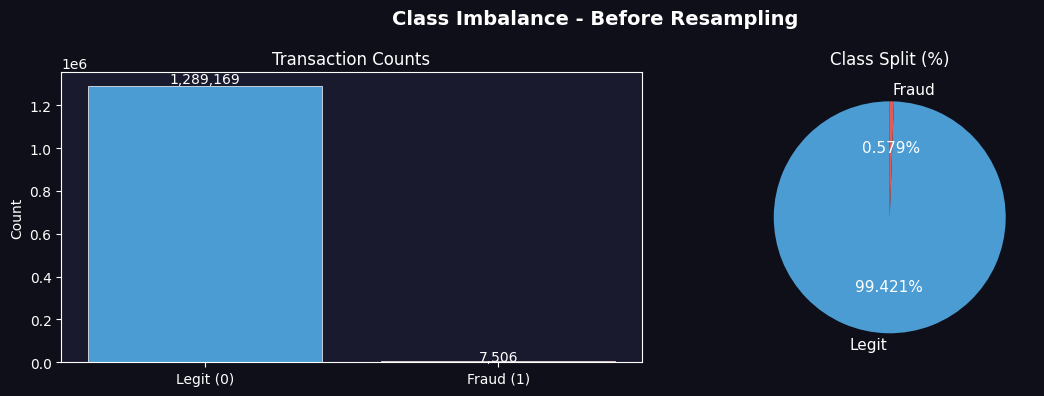

In [3]:
# ─────────────────────────────────────────────────────────────
#Class Imbalance Analysis
# ─────────────────────────────────────────────────────────────
# In this cell, I check how imbalanced the target variable is.
# This is a very important step in fraud detection because fraud cases are usually rare compared to legitimate transactions.
#
# The imbalance level affects almost everything later:
#   - whether I should use SMOTE
#   - which evaluation metric matters most
#   - whether the default threshold of 0.50 is appropriate
#
# so, this cell helps define the modeling strategy.

# Count how many transactions belong to each class in the target column.

fraud_counts = df['is_fraud'].value_counts()

# Calculate the percentage of fraud transactions in the full dataset.
fraud_rate = df['is_fraud'].mean() * 100

# Calculate the imbalance ratio:
# how many legitimate transactions exist for every 1 fraud transaction.
imbalance_ratio = int(fraud_counts[0] / fraud_counts[1])


# ─────────────────────────────────────────────────────────────
# Print class distribution summary
# ─────────────────────────────────────────────────────────────
print('─── Class Distribution ──────────────────────')
print(f'  Legitimate : {fraud_counts[0]:>10,}  ({100 - fraud_rate:.3f}%)')
print(f'  Fraud      : {fraud_counts[1]:>10,}  ({fraud_rate:.3f}%)')
print(f'  Ratio      : 1 fraud per {imbalance_ratio:,} legitimate transactions')
print()

# Based on this distribution, print the main strategy decisions
# that will guide the next ML steps.
print('   Strategy decisions:')
print('     - Use SMOTE on training fold ONLY (never on test)')
print('     - Primary metric  → PR-AUC (not accuracy/ROC-AUC)')
print('     - Secondary metric → F2-Score (recall weighted 2×)')
print('     - Threshold tuning after training (default 0.5 is wrong here)')


# ─────────────────────────────────────────────────────────────
# Visualize the imbalance
# ─────────────────────────────────────────────────────────────
# Create a figure with two side-by-side plots:
#   1) bar chart for raw counts
#   2) pie chart for percentage split
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0f0f1a')

# Main title for the full figure
fig.suptitle(
    'Class Imbalance - Before Resampling',
    fontsize=14,
    fontweight='bold',
    color='white'
)


# ─────────────────────────────────────────────────────────────
# Left plot: bar chart
# ─────────────────────────────────────────────────────────────
bars = axes[0].bar(
    ['Legit (0)', 'Fraud (1)'],
    fraud_counts.values,
    color=[PALETTE['legit'], PALETTE['fraud']],
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_title('Transaction Counts', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#1a1a2e')

# Add the exact count value above each bar
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{int(val):,}',
        ha='center',
        color='white',
        fontsize=10
    )


# ─────────────────────────────────────────────────────────────
# Right plot: pie chart
# ─────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    fraud_counts.values,
    labels=['Legit', 'Fraud'],
    autopct='%1.3f%%',
    colors=[PALETTE['legit'], PALETTE['fraud']],
    startangle=90,
    textprops={'color': 'white', 'fontsize': 11}
)

# Make the percentage labels inside the pie chart white as well
for at in autotexts:
    at.set_color('white')

axes[1].set_title('Class Split (%)', color='white')
axes[1].set_facecolor('#1a1a2e')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────
plt.tight_layout()

# Save the chart into the reports folder so I can reuse it later
# in documentation, GitHub, or Power BI project notes.
plt.savefig(
    REPORTS_DIR / 'class_imbalance.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

The target column `is_fraud` is highly imbalanced. Out of 1,296,675 total transactions, only 7,506 transactions are fraud, which represents about 0.579% of the dataset. This means there is approximately 1 fraud transaction for every 171 legitimate transactions.

Because of this imbalance, accuracy is not a reliable metric for this project. A model could achieve very high accuracy by predicting almost every transaction as legitimate, but it would still fail to catch fraud cases.

For this reason, I will focus on PR-AUC as the main evaluation metric because it is more useful for imbalanced classification problems. I will also use F2-score as a secondary metric because fraud detection should give more weight to recall, meaning the model should try to catch as many fraud cases as possible.

This imbalance also explains why I will apply SMOTE only to the training data and keep the test data untouched. The test set should stay realistic so the final evaluation reflects how the model would perform on real future transactions.

Finally, I will tune the prediction threshold after training because the default 0.50 threshold is usually not the best choice for fraud detection.

In [4]:
# ─────────────────────────────────────────────────────────────
# Feature Selection
# ─────────────────────────────────────────────────────────────
# In this cell, I choose which columns should be used as model features.
#
# The model should only learn from useful business and transaction signals.
# It should not learn from IDs, personal information, raw timestamps, or columns that were created using the fraud label.
#
# This step is important because bad feature selection can make the model look better than it really is, especially if data leakage exists.

# Target column: this is the value the model will try to predict.
# is_fraud = 0 means legitimate transaction
# is_fraud = 1 means fraudulent transaction
TARGET = 'is_fraud'


# ─────────────────────────────────────────────────────────────
# Columns that should not be used as model features
# ─────────────────────────────────────────────────────────────



DROP_CANDIDATES = [
    # Raw datetime column.
    # I already created separate time features from it, such as:
    # transaction_hour, transaction_day, transaction_month, and time_of_day.
    'trans_date_trans_time',

    # Unique transaction identifier.
    # It identifies a row, but it does not teach the model a general fraud pattern.
    'transaction_id',

    # Unique transaction number.
    # This is also an ID, so the model should not learn from it.
    'trans_num',

    # Masked card number.
    # Even though it is masked, it is still an identifier, not a behavioral feature.
    'cc_num_masked',

    # Very specific location fields.
    # I keep more general location features like province_code and city_tier instead.
    'city_ca',
    'postal_code',

    # Raw coordinates.
    # I already have dist_km, which is a cleaner distance feature.
    'lat',
    'long',
    'merch_lat',
    'merch_long',

    # Specific merchant name.
    # I keep category instead because it is more general and easier to explain.
    'merchant_ca',

    # Columns created from fraud logic.
    # These can leak information from the target or make the model look too strong.
    'fraud_type',
    'fraud_score',
    'risk_tier',
]


# ─────────────────────────────────────────────────────────────
# Apply the drop list safely
# ─────────────────────────────────────────────────────────────
# Only drop columns that actually exist in the dataframe.
drop_cols = [c for c in DROP_CANDIDATES if c in df.columns]

# The final feature list includes every column except:
#   - the dropped columns
#   - the target column is_fraud
feature_cols = [c for c in df.columns if c not in drop_cols + [TARGET]]


# ─────────────────────────────────────────────────────────────
# Print selected features
# ─────────────────────────────────────────────────────────────
print(f'Dropped   : {len(drop_cols)} columns → {drop_cols}')
print(f'\nFeatures  : {len(feature_cols)} columns')
print()

# Display the remaining feature columns and their data types.
# This helps me confirm what will go into the model before encoding and training.
for col in feature_cols:
    print(f'  {col:<30} {str(df[col].dtype)}')

Dropped   : 14 columns → ['trans_date_trans_time', 'transaction_id', 'trans_num', 'cc_num_masked', 'city_ca', 'postal_code', 'lat', 'long', 'merch_lat', 'merch_long', 'merchant_ca', 'fraud_type', 'fraud_score', 'risk_tier']

Features  : 15 columns

  category                       object
  gender                         object
  province_code                  object
  city_tier                      object
  dist_km                        float64
  amount_cad                     float64
  transaction_hour               int64
  transaction_day                object
  transaction_month              object
  is_weekend                     int64
  time_of_day                    object
  is_amount_outlier              int64
  amount_bin                     object
  age_group                      object
  amount_zscore                  float64


In this step, I selected the final input features that will be used by the machine learning models.

I dropped 14 columns that were not suitable for training. These included identifiers such as `transaction_id`, `trans_num`, and `cc_num_masked`, raw timestamp and coordinate columns, highly specific location or merchant fields, and fraud-derived columns such as `fraud_type`, `fraud_score`, and `risk_tier`.

This step is important because the model should learn from real transaction behavior, not from IDs or columns that already contain fraud-related logic. Keeping those columns could cause data leakage or make the model look unrealistically strong.

After feature selection, 15 columns remained. These features describe the transaction amount, distance, time, customer/location grouping, category, and amount behavior. This gives the model a cleaner and more explainable set of inputs for fraud detection.

In [5]:
# ─────────────────────────────────────────────────────────────
# Encode Categorical Features
# ─────────────────────────────────────────────────────────────
# In this cell, I prepare the final ML dataframe.
#
#
#
# I use LabelEncoder here to convert each category into an integer code.
# For example:
#   gender: F, M  →  0, 1
#   time_of_day: Late Night, Morning, Afternoon  →  numeric labels
#
# I also save all encoders so I can reuse them later when decoding results or applying the same transformation to new data.

# Keep only the selected feature columns and the target column.
# This creates a clean modeling dataframe.
df_ml = df[feature_cols + [TARGET]].copy()


# ─────────────────────────────────────────────────────────────
# Identify categorical columns
# ─────────────────────────────────────────────────────────────
# Select all columns with text/category values.
# These columns need encoding before model training.
cat_cols = df_ml.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Encoding {len(cat_cols)} categorical columns:')


# ─────────────────────────────────────────────────────────────
# Encode each categorical column
# ─────────────────────────────────────────────────────────────
# le_registry will store one LabelEncoder per column.
# This is useful because each column has its own set of categories.
le_registry = {}

for col in cat_cols:
    # Create a new encoder for the current column.
    le = LabelEncoder()

    # Convert the column to string first to avoid issues with mixed types.
    # Then fit the encoder and replace the original text values with numbers.
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

    # Save the fitted encoder in the registry using the column name as the key.
    le_registry[col] = le

    # Store the category names so I can quickly review what was encoded.
    classes = list(le.classes_)

    # If a column has many categories, show only the first 5 to keep output clean.
    suffix = '...' if len(classes) > 5 else ''

    print(
        f'  {col:<25} → {len(classes)} classes: '
        f'{classes[:5]}{suffix}'
    )


# ─────────────────────────────────────────────────────────────
# Save encoders
# ─────────────────────────────────────────────────────────────
# Saving the encoders is important because the same category-to-number
# mapping should be reused later when scoring new data.
joblib.dump(le_registry, MODELS_DIR / 'label_encoders.pkl')

print(f'\n Encoders saved → {MODELS_DIR / "label_encoders.pkl"}')
print(f'   Final shape: {df_ml.shape}')

Encoding 9 categorical columns:
  category                  → 14 classes: ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos']...
  gender                    → 2 classes: ['F', 'M']
  province_code             → 8 classes: ['AB', 'BC', 'MB', 'NB', 'NS']...
  city_tier                 → 4 classes: ['Large City', 'Metro', 'Mid City', 'Small Town']
  transaction_day           → 7 classes: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday']...
  transaction_month         → 12 classes: ['April', 'August', 'December', 'February', 'January']...
  time_of_day               → 4 classes: ['Afternoon', 'Evening', 'Late Night', 'Morning']
  amount_bin                → 6 classes: ['$0-20', '$100-200', '$20-50', '$200-500', '$50-100']...
  age_group                 → 5 classes: ['18-25', '26-35', '36-50', '51-65', '65+']

 Encoders saved → models\label_encoders.pkl
   Final shape: (1296675, 16)



In this step, I converted the categorical columns into numeric values so they can be used by the machine learning models.

The dataset contained 9 categorical columns, including transaction category, gender, province, city tier, transaction day, transaction month, time of day, amount bin, and age group. Each unique text value was converted into a numeric label using `LabelEncoder`.

The final modeling dataset now contains 1,296,675 rows and 16 columns, which includes 15 selected features and the target column `is_fraud`.

I also saved the fitted encoders into `label_encoders.pkl`. This is important because the same category-to-number mapping should be reused later when scoring new data or interpreting model outputs.

In [6]:
# ─────────────────────────────────────────────────────────────
# Time-Aware Train / Test Split
# ─────────────────────────────────────────────────────────────
# In this cell, I split the dataset into training and testing sets.
#
# For transaction data, I should not use a random split because it can mix future transactions into the training data. 
# That would make the model look better than it really is.
#
# Instead, I use a chronological split:
#   - older transactions → training set
#   - newer transactions → testing set
#
#

# Use the first 80% of transactions for training.
# Since the dataframe was already sorted by transaction date in Cell 2,
# this means the model will train on earlier transactions.
TRAIN_FRAC = 0.80

# Find the row index where the train/test split should happen.
split_idx = int(len(df_ml) * TRAIN_FRAC)


# ─────────────────────────────────────────────────────────────
# Get date ranges for documentation
# ─────────────────────────────────────────────────────────────
# These dates are taken from the original df because it still contains the transaction timestamp column.
#
# df_ml does not include trans_date_trans_time because it was removed during feature selection.

train_start = df['trans_date_trans_time'].iloc[0].date()
train_end = df['trans_date_trans_time'].iloc[split_idx - 1].date()

test_start = df['trans_date_trans_time'].iloc[split_idx].date()
test_end = df['trans_date_trans_time'].iloc[-1].date()


# ─────────────────────────────────────────────────────────────
# Separate features and target
# ─────────────────────────────────────────────────────────────
# X contains the input features that the model will learn from.
# y contains the target column that the model will try to predict.

X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]


# ─────────────────────────────────────────────────────────────
# Split into train and test sets
# ─────────────────────────────────────────────────────────────
# The first 80% of rows become the training set.
# The last 20% of rows become the testing set.
#
# Because the data is sorted by time, this keeps the split chronological.

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()


# ─────────────────────────────────────────────────────────────
# Print split summary
# ─────────────────────────────────────────────────────────────
# This output helps me confirm:
#   - the train and test date ranges
#   - the number of rows in each set
#   - the fraud rate in each set
#   - the number of features used by the model

print('─── Split Summary ──────────────────────────────')

print(f'  Train : {train_start} → {train_end}')
print(
    f'          {len(X_train):>10,} rows | '
    f'Fraud: {y_train.sum():,} ({y_train.mean() * 100:.3f}%)'
)

print(f'  Test  : {test_start} → {test_end}')
print(
    f'          {len(X_test):>10,} rows | '
    f'Fraud: {y_test.sum():,} ({y_test.mean() * 100:.3f}%)'
)

print(f'\n  Features : {X_train.shape[1]} columns')
print(f'  {list(X_train.columns)}')

─── Split Summary ──────────────────────────────
  Train : 2019-01-01 → 2020-03-06
           1,037,340 rows | Fraud: 5,968 (0.575%)
  Test  : 2020-03-06 → 2020-06-21
             259,335 rows | Fraud: 1,538 (0.593%)

  Features : 15 columns
  ['category', 'gender', 'province_code', 'city_tier', 'dist_km', 'amount_cad', 'transaction_hour', 'transaction_day', 'transaction_month', 'is_weekend', 'time_of_day', 'is_amount_outlier', 'amount_bin', 'age_group', 'amount_zscore']


In this step, I split the dataset into training and testing sets using a chronological approach.

The model will train on older transactions from **January 1, 2019 to March 6, 2020**, and it will be tested on newer transactions from **March 6, 2020 to June 21, 2020**. This is more realistic for fraud detection because, in real life, a model learns from past transactions and is used to predict fraud on future transactions.

The training set contains **1,037,340 rows**, including **5,968 fraud cases**. The test set contains **259,335 rows**, including **1,538 fraud cases**.

The fraud rate is very similar in both sets: **0.575%** in training and **0.593%** in testing. This is a good sign because the test set has a realistic fraud distribution and can be used to evaluate the model fairly.

After the split, the model will use **15 selected features**, including transaction category, amount, distance, time-based features, province, city tier, amount behavior, and age group.

In [7]:
# ─────────────────────────────────────────────────────────────
# Baseline Model — Logistic Regression
# ─────────────────────────────────────────────────────────────
# In this cell, I train my first machine learning model.
#
# I start with Logistic Regression because it is a simple and reliable baseline model.
# The goal is not for it to be the best model, but to create a first performance score that the stronger models should beat later.
#
# Since this is a fraud detection problem and the data is highly imbalanced, I use class_weight='balanced'. 
# This tells the model to give more importance to the rare fraud class instead of treating both classes as equally common.

# Logistic Regression works better when numeric features are scaled.
# So I use a Pipeline that first scales the features, then trains the model.
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),

    ('clf', LogisticRegression(
        class_weight='balanced',  # helps the model pay more attention to fraud cases
        max_iter=1000,            # gives the model enough iterations to converge
        random_state=SEED,
        n_jobs=-1                 # uses available CPU cores where supported
    ))
])


# ─────────────────────────────────────────────────────────────
# Train the baseline model
# ─────────────────────────────────────────────────────────────
print('Training Logistic Regression baseline...')

# Fit the pipeline on the training data only.
baseline_pipe.fit(X_train, y_train)


# ─────────────────────────────────────────────────────────────
# Generate predictions
# ─────────────────────────────────────────────────────────────
# y_pred_lr gives the final class prediction: 0 or 1.
# This uses the default threshold of 0.50.
y_pred_lr = baseline_pipe.predict(X_test)

# y_prob_lr gives the fraud probability for each transaction.
# [:, 1] means I only want the probability of class 1, which is fraud.
y_prob_lr = baseline_pipe.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate model performance
# ─────────────────────────────────────────────────────────────
# PR-AUC is the main metric because the dataset is highly imbalanced.
# It focuses more on how well the model handles the fraud class.
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

# ROC-AUC is also calculated as a secondary metric.
# It is useful, but it can sometimes look too optimistic on imbalanced data.
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

# F2-score gives more weight to recall.
# This is useful in fraud detection because missing fraud is usually more costly
# than reviewing extra suspicious transactions.
f2_lr = fbeta_score(y_test, y_pred_lr, beta=2)


# ─────────────────────────────────────────────────────────────
# Print baseline results
# ─────────────────────────────────────────────────────────────
line = '─' * 50

print(f'\n{line}')
print('  BASELINE — Logistic Regression')
print(f'  PR-AUC   (main)  : {pr_auc_lr:.4f}   ← beat this later')
print(f'  ROC-AUC          : {roc_auc_lr:.4f}')
print(f'  F2-Score         : {f2_lr:.4f}')
print(line)
print()

# Detailed classification report.
# This shows precision, recall, and F1-score for both legitimate and fraud classes.
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Legit', 'Fraud']
))


# ─────────────────────────────────────────────────────────────
# Save the trained model
# ─────────────────────────────────────────────────────────────
# Saving the model lets me reuse it later for comparison, scoring, or deployment.
joblib.dump(baseline_pipe, MODELS_DIR / 'model_logreg.pkl')

print(f' Saved → {MODELS_DIR / "model_logreg.pkl"}')

Training Logistic Regression baseline...

──────────────────────────────────────────────────
  BASELINE — Logistic Regression
  PR-AUC   (main)  : 0.1625   ← beat this later
  ROC-AUC          : 0.9182
  F2-Score         : 0.2849
──────────────────────────────────────────────────

              precision    recall  f1-score   support

       Legit       1.00      0.95      0.97    257797
       Fraud       0.08      0.79      0.15      1538

    accuracy                           0.95    259335
   macro avg       0.54      0.87      0.56    259335
weighted avg       0.99      0.95      0.97    259335

 Saved → models\model_logreg.pkl


In this step, I trained a Logistic Regression model as the baseline for the fraud detection pipeline.

The baseline achieved a PR-AUC of **0.1625**, ROC-AUC of **0.9182**, and F2-score of **0.2849**. Since this is a highly imbalanced fraud problem, I will treat PR-AUC as the main performance benchmark instead of accuracy.

The model achieved a fraud recall of **0.79**, meaning it caught most fraud cases in the test set. However, fraud precision was only **0.08**, which means many transactions flagged as fraud were actually legitimate. This is expected for an early baseline model on an imbalanced dataset.

This result gives me a starting point. The next models should try to improve the PR-AUC and F2-score while keeping fraud recall strong.


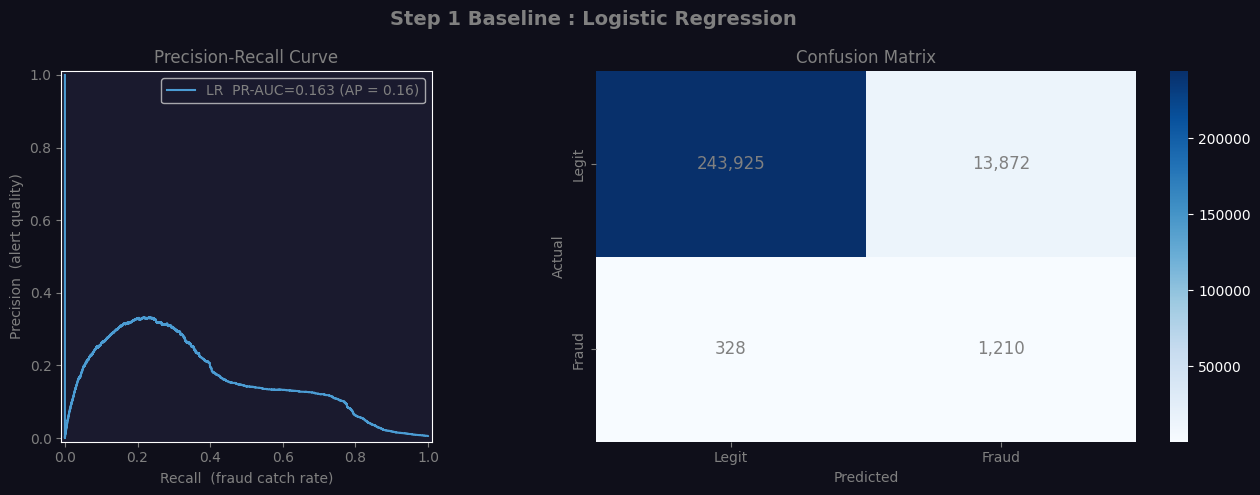


 PR-AUC to beat on Step 2: 0.1625


In [8]:
# ─────────────────────────────────────────────────────────────
# Step 1: Evaluation Plots
# ─────────────────────────────────────────────────────────────
# In this cell, I visualize the performance of the baseline Logistic Regression model.
#
# Instead of looking only at printed metrics, I create two plots:
#   1) Precision-Recall Curve
#   2) Confusion Matrix
#
# These plots help me understand how well the model handles the fraud class and give me a visual baseline to compare against stronger models later.

# Create a figure with 2 side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')

# Add a title for the full figure
fig.suptitle(
    'Step 1 Baseline : Logistic Regression',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Left Plot | Precision-Recall Curve
# ─────────────────────────────────────────────────────────────
# This chart shows the trade-off between:
#   - Recall    → how many fraud cases the model catches
#   - Precision → how many flagged fraud alerts are actually fraud
#
# This is especially important for fraud detection because the dataset is highly imbalanced, so PR-AUC is more meaningful than accuracy.

ax = axes[0]
ax.set_facecolor('#1a1a2e')

PrecisionRecallDisplay.from_predictions(
    y_test,          # true labels from the test set
    y_prob_lr,       # predicted fraud probabilities from Logistic Regression
    ax=ax,
    name=f'LR  PR-AUC={pr_auc_lr:.3f}',
    color=PALETTE['legit']
)

ax.set_title('Precision-Recall Curve', color='gray')
ax.set_xlabel('Recall  (fraud catch rate)', color='gray')
ax.set_ylabel('Precision  (alert quality)', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray')


# ─────────────────────────────────────────────────────────────
# Right Plot | Confusion Matrix
# ─────────────────────────────────────────────────────────────
# The confusion matrix shows how many predictions were:
#   - True Legit
#   - False Fraud Alert
#   - Missed Fraud
#   - Correctly Detected Fraud
#
# This makes it easier to see the real behavior of the model.

ax = axes[1]
ax.set_facecolor('#1a1a2e')

# Build confusion matrix from true labels and predicted classes
cm = confusion_matrix(y_test, y_pred_lr)

# Plot the confusion matrix as a heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt=',',
    cmap='Blues',
    ax=ax,
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud'],
    annot_kws={'size': 12, 'color': 'gray'}
)

ax.set_title('Confusion Matrix', color='gray')
ax.set_xlabel('Predicted', color='gray')
ax.set_ylabel('Actual', color='gray')
ax.tick_params(colors='gray')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / 'step1_baseline_logreg.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

# Print the baseline PR-AUC so I remember the score that the next models need to beat.
print(f'\n PR-AUC to beat on Step 2: {pr_auc_lr:.4f}')

The Logistic Regression baseline correctly detected **1,210 fraud transactions** out of **1,538 total fraud cases** in the test set. This means the model caught most fraud cases, with a fraud recall of about **79%**.

However, the model also incorrectly flagged **13,872 legitimate transactions** as fraud. This explains why the fraud precision is low. The model is sensitive to fraud, but it still creates many false alerts.

The Precision-Recall Curve shows the trade-off between catching fraud and keeping alerts accurate. The baseline PR-AUC is **0.1625**, which will be used as the score that the next models should try to beat.


**************************************************************************************************************************************************************************************

**************************************************************************************************************************************************************************************

# Step 2 - SMOTE, Random Forest, XGBoost, and Model Comparison

In Step 1, I created my first machine learning baseline using Logistic Regression. The baseline achieved a **PR-AUC of 0.1625** and an **F2-Score of 0.2849**.

The good part is that the model was able to catch many fraud cases. However, it also flagged many legitimate transactions as fraud, which means the alerts were not very clean yet. In other words, the model had strong recall, but the precision still needs improvement.

In Step 2, I will try to improve the baseline by training two stronger models: **Random Forest** and **XGBoost**.

Since fraud cases are much fewer than legitimate transactions, I will first use **SMOTE** on the training data only. This helps balance the training set by creating synthetic fraud examples, giving the model more fraud patterns to learn from. I will not apply SMOTE to the test data because the test set should stay realistic and represent future unseen transactions.

For XGBoost, I will handle the imbalance using `scale_pos_weight` instead of SMOTE. This is a common approach for XGBoost because it allows the model to give more weight to the rare fraud class during training.

After training the models, I will compare Logistic Regression, Random Forest, and XGBoost side by side using the same metrics: **PR-AUC**, **ROC-AUC**, **F2-Score**, **precision**, and **recall**.

By the end of this step, I want to choose the strongest model and carry it forward to Step 3, where I will tune the prediction threshold.

In [9]:
# ─────────────────────────────────────────────────────────────
# SMOTE Resampling
# ─────────────────────────────────────────────────────────────
# In this cell, I handle the class imbalance in the training data.
#
# Fraud cases are very rare compared to legitimate transactions, so if I train stronger models directly on the original training data, they may focus too much on the majority class and miss fraud patterns.
#
# To help with this, I use SMOTE, which creates synthetic fraud examples based on the existing fraud cases in the training data.
#
# Very important:
#   - SMOTE is applied to the training set only
#   - The test set is not changed
#   - This keeps the final evaluation realistic because the test set still looks like real future transaction data
#
# I use sampling_strategy=0.3 instead of forcing a 50/50 balance.
# This means the number of fraud examples after SMOTE will become 30% of the# legitimate class size. 
# This is a softer balance and avoids creating too many synthetic fraud records.

# ─────────────────────────────────────────────────────────────
# Class counts before SMOTE
# ─────────────────────────────────────────────────────────────
# These numbers come from y_train, which is the target column for the chronological training set created in Step 1.
print('─── Before SMOTE ────────────────────────────')
print(f'  Fraud      : {y_train.sum():,}  ({y_train.mean() * 100:.3f}%)')
print(f'  Legitimate : {(y_train == 0).sum():,}')
print(f'  Total      : {len(y_train):,}')


# ─────────────────────────────────────────────────────────────
# Apply SMOTE to the training data only
# ─────────────────────────────────────────────────────────────
# X_train contains the training features.
# y_train contains the training labels.
#
# fit_resample() learns from the training data and creates synthetic fraud rows.
# I do not run this on X_test or y_test.
smote = SMOTE(
    sampling_strategy=0.3,
    random_state=SEED
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


# ─────────────────────────────────────────────────────────────
# Class counts after SMOTE
# ─────────────────────────────────────────────────────────────
# After resampling, the number of legitimate transactions stays the same.
# The number of fraud transactions increases because SMOTE created synthetic fraud examples for training.
print()
print('─── After SMOTE (training only) ─────────────')
print(f'  Fraud      : {y_train_sm.sum():,}  ({y_train_sm.mean() * 100:.2f}%)')
print(f'  Legitimate : {(y_train_sm == 0).sum():,}')
print(f'  Total      : {len(X_train_sm):,}')


# ─────────────────────────────────────────────────────────────
# Confirm the test set was not changed
# ─────────────────────────────────────────────────────────────
# The test set must keep its original fraud rate because it represents real-world future data.
print()
print('─── Test Set (unchanged) ────────────────────')
print(f'  Fraud      : {y_test.sum():,}  ({y_test.mean() * 100:.3f}%)')
print(f'  Legitimate : {(y_test == 0).sum():,}')
print(f'  Total      : {len(y_test):,}')
print()
print('  Test set preserved - real-world distribution intact')

─── Before SMOTE ────────────────────────────
  Fraud      : 5,968  (0.575%)
  Legitimate : 1,031,372
  Total      : 1,037,340

─── After SMOTE (training only) ─────────────
  Fraud      : 309,411  (23.08%)
  Legitimate : 1,031,372
  Total      : 1,340,783

─── Test Set (unchanged) ────────────────────
  Fraud      : 1,538  (0.593%)
  Legitimate : 257,797
  Total      : 259,335

  Test set preserved - real-world distribution intact


In this step, I applied SMOTE to the training data only to help reduce the class imbalance problem.

Before SMOTE, the training set had **5,968 fraud transactions** and **1,031,372 legitimate transactions**, with a fraud rate of only **0.575%**. This means fraud cases were very rare, which could make stronger models focus too much on legitimate transactions.

After applying SMOTE with `sampling_strategy=0.3`, the number of fraud examples increased to **309,411**, while the number of legitimate transactions stayed the same. This made the fraud class about **23.08%** of the resampled training data.

The test set was not changed. It still has a fraud rate of **0.593%**, which keeps the evaluation realistic and closer to real-world transaction behavior.

This resampled training set will be used to train the Random Forest model in the next step.

In [10]:
# ─────────────────────────────────────────────────────────────
# Random Forest Model
# ─────────────────────────────────────────────────────────────
# In this cell, I train a Random Forest model as the first stronger model after the Logistic Regression baseline.
#
# Random Forest works by building many decision trees and combining their predictions.
# A single decision tree can overfit easily, but a forest of many trees is usually more stable and better at learning non-linear patterns.
#
# I train this model on the SMOTE-resampled training data because the original training data has very few fraud cases.
# SMOTE gives the model more fraud examples to learn from.
#
#
# Key settings:
#   n_estimators=200        : build 200 trees
#   max_depth=12            : limit tree depth to reduce overfitting
#   min_samples_leaf=10     : require at least 10 samples in each final leaf
#   class_weight='balanced' : give extra importance to the fraud class
#   n_jobs=-1               : use all available CPU cores

print('Training Random Forest...')
print()


# ─────────────────────────────────────────────────────────────
# Create the Random Forest model
# ─────────────────────────────────────────────────────────────
# These parameters are a balanced starting point:
# not too simple, but also controlled enough to avoid extreme overfitting.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)


# ─────────────────────────────────────────────────────────────
# Train on SMOTE-resampled training data
# ─────────────────────────────────────────────────────────────
# X_train_sm and y_train_sm were created in the previous cell using SMOTE.
# The model learns from this adjusted training set.
rf_model.fit(X_train_sm, y_train_sm)


# ─────────────────────────────────────────────────────────────
# Generate predictions on the original test set
# ─────────────────────────────────────────────────────────────
# y_pred_rf gives the final class prediction: 0 = legit, 1 = fraud.
# This uses the default threshold of 0.50 for now.
# Threshold tuning will happen later in Step 3.
y_pred_rf = rf_model.predict(X_test)

# y_prob_rf gives the fraud probability for each transaction.
# These probabilities are used for PR-AUC, ROC-AUC, and threshold tuning.
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate model performance
# ─────────────────────────────────────────────────────────────
# PR-AUC is the main metric because fraud is very rare.
# ROC-AUC is included as a secondary metric.
# F2-score gives more weight to recall, which matters in fraud detection.
pr_auc_rf = average_precision_score(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
f2_rf = fbeta_score(y_test, y_pred_rf, beta=2)


# ─────────────────────────────────────────────────────────────
# Print Random Forest results
# ─────────────────────────────────────────────────────────────
# I compare PR-AUC directly with the Logistic Regression baseline.
# A positive delta means Random Forest improved over the baseline.
line = '─' * 50

print(f'{line}')
print('  Random Forest')
print(
    f'  PR-AUC   (main)  : {pr_auc_rf:.4f}   '
    f'(baseline: {pr_auc_lr:.4f},  Δ={pr_auc_rf - pr_auc_lr:+.4f})'
)
print(f'  ROC-AUC          : {roc_auc_rf:.4f}')
print(f'  F2-Score         : {f2_rf:.4f}')
print(f'{line}')
print()

# The classification report shows precision, recall, and F1-score for both legitimate and fraud transactions.
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Legit', 'Fraud']
))


# ─────────────────────────────────────────────────────────────
# Save the trained model
# ─────────────────────────────────────────────────────────────
# Saving the model allows me to reuse it later without retraining.
joblib.dump(rf_model, MODELS_DIR / 'model_random_forest.pkl')

print(f' Saved → {MODELS_DIR / "model_random_forest.pkl"}')

Training Random Forest...

──────────────────────────────────────────────────
  Random Forest
  PR-AUC   (main)  : 0.7173   (baseline: 0.1625,  Δ=+0.5548)
  ROC-AUC          : 0.9938
  F2-Score         : 0.5991
──────────────────────────────────────────────────

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99    257797
       Fraud       0.25      0.91      0.40      1538

    accuracy                           0.98    259335
   macro avg       0.63      0.95      0.69    259335
weighted avg       1.00      0.98      0.99    259335

 Saved → models\model_random_forest.pkl


The Random Forest model performed much better than the Logistic Regression baseline.

The PR-AUC increased from **0.1625** to **0.7173**, which is an improvement of **+0.5548**. Since PR-AUC is the main metric for this imbalanced fraud detection problem, this is a strong improvement.

The model achieved a fraud recall of **0.91**, meaning it caught about 91% of fraud transactions in the test set. It also improved fraud precision to **0.25**, compared with 0.08 from the Logistic Regression baseline. This means the Random Forest model created cleaner fraud alerts while also catching more fraud cases.

The F2-score also improved from **0.2849** to **0.5991**, which is important because F2-score gives more weight to recall. In fraud detection, this matters because missing fraud is usually more costly than reviewing extra suspicious transactions.

Overall, Random Forest is currently the strongest model so far and will be compared against XGBoost in the next step.

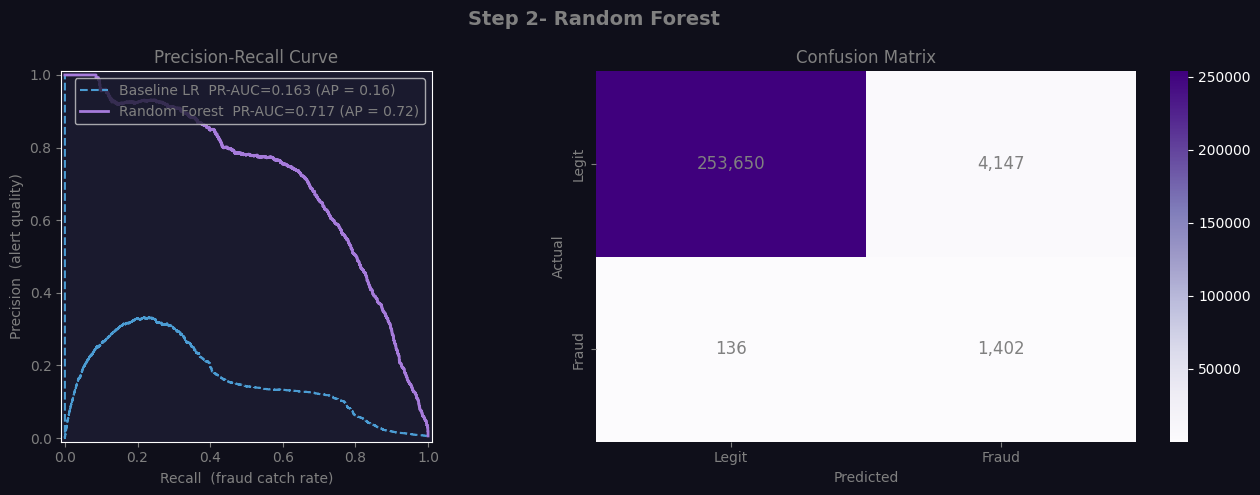

In [11]:
# ─────────────────────────────────────────────────────────────
# Random Forest Evaluation Plots
# ─────────────────────────────────────────────────────────────
# In this cell, I visualize how well the Random Forest model performs on the untouched test set.
#
# I use the same two-plot layout as the baseline model so the comparison stays easy and consistent:
#   1) Precision-Recall Curve
#   2) Confusion Matrix
#
# I also overlay the Logistic Regression baseline PR curve so I can see the improvement directly.

# Create a figure with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')

# Add one title for the full figure
fig.suptitle(
    'Step 2- Random Forest',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Left Plot | Precision-Recall Curve
# ─────────────────────────────────────────────────────────────
# This plot shows the trade-off between:
#   - Recall   : how many fraud cases the model catches
#   - Precision: how reliable the fraud alerts are
#
# I plot both:
#   - Logistic Regression baseline
#   - Random Forest
#
# If the Random Forest curve sits higher than the baseline curve, that means it is performing better overall.

ax = axes[0]
ax.set_facecolor('#1a1a2e')

# Baseline Logistic Regression curve
PrecisionRecallDisplay.from_predictions(
    y_test,            # true labels from the test set
    y_prob_lr,         # fraud probabilities from Logistic Regression
    ax=ax,
    name=f'Baseline LR  PR-AUC={pr_auc_lr:.3f}',
    color=PALETTE['legit'],
    linestyle='--',
    linewidth=1.5
)

# Random Forest curve
PrecisionRecallDisplay.from_predictions(
    y_test,            # same true labels
    y_prob_rf,         # fraud probabilities from Random Forest
    ax=ax,
    name=f'Random Forest  PR-AUC={pr_auc_rf:.3f}',
    color=PALETTE['accent'],
    linewidth=2
)

ax.set_title('Precision-Recall Curve', color='gray')
ax.set_xlabel('Recall  (fraud catch rate)', color='gray')
ax.set_ylabel('Precision  (alert quality)', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray')


# ─────────────────────────────────────────────────────────────
# Right Plot | Confusion Matrix
# ─────────────────────────────────────────────────────────────
# The confusion matrix shows the exact number of:
#   - correctly predicted legitimate transactions
#   - legitimate transactions incorrectly flagged as fraud
#   - fraud transactions missed by the model
#   - fraud transactions correctly detected
#
# This helps me move beyond percentages and see the real count impact.

ax = axes[1]
ax.set_facecolor('#1a1a2e')

# Build confusion matrix using the true labels and Random Forest predictions
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix as a heatmap
sns.heatmap(
    cm_rf,
    annot=True,
    fmt=',',
    cmap='Purples',
    ax=ax,
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud'],
    annot_kws={'size': 12, 'color': 'gray'}
)

ax.set_title('Confusion Matrix', color='gray')
ax.set_xlabel('Predicted', color='gray')
ax.set_ylabel('Actual', color='gray')
ax.tick_params(colors='gray')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / 'step2_random_forest.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

The Random Forest evaluation plots show a clear improvement over the Logistic Regression baseline.

The Precision-Recall Curve for Random Forest is much higher than the baseline curve, and the PR-AUC increased from **0.163** to **0.717**. This means Random Forest is much better at balancing fraud recall and alert quality.

The confusion matrix also shows a strong improvement. Random Forest correctly detected **1,402 fraud transactions** out of **1,538** total fraud cases in the test set, missing only **136** fraud cases. It also reduced false fraud alerts to **4,147**, compared with **13,872** false alerts from Logistic Regression.

Overall, Random Forest improved both fraud detection and alert quality. It caught more fraud cases while creating fewer false positives, making it the strongest model so far.

In [12]:
# ─────────────────────────────────────────────────────────────
# XGBoost Model
# ─────────────────────────────────────────────────────────────
# In this cell, I train an XGBoost model.
#
# XGBoost is a gradient boosting model. Unlike Random Forest, which builds many trees independently, XGBoost builds trees one after another.
# Each new tree tries to correct the mistakes made by the previous trees.
#
# This usually works very well on structured/tabular data like transaction data.
#
# For XGBoost, I do not use SMOTE. Instead, I use scale_pos_weight, which is XGBoost's built-in way to handle class imbalance.
#
# scale_pos_weight tells the model to give more importance to the fraud class.
# This is useful because fraud cases are rare compared to legitimate transactions.
#
# Formula:
#   scale_pos_weight = number of legitimate transactions / number of fraud transactions
#
# I also use early stopping. This allows the model to stop training when the validation performance stops improving, which helps reduce overfitting.


# ─────────────────────────────────────────────────────────────
# Create a validation split from the training data
# ─────────────────────────────────────────────────────────────
#
# Since this is time-based data, I keep the split chronological:
#   - earlier part of X_train : actual training
#   - later part of X_train   : validation for early stopping

VAL_FRAC = 0.20
val_idx = int(len(X_train) * (1 - VAL_FRAC))

X_train_xgb = X_train.iloc[:val_idx].copy()
y_train_xgb = y_train.iloc[:val_idx].copy()

X_val_xgb = X_train.iloc[val_idx:].copy()
y_val_xgb = y_train.iloc[val_idx:].copy()

print('─── XGBoost Train / Validation Split ─────────')
print(f'  Train      : {len(X_train_xgb):,} rows | Fraud: {y_train_xgb.sum():,} ({y_train_xgb.mean() * 100:.3f}%)')
print(f'  Validation : {len(X_val_xgb):,} rows | Fraud: {y_val_xgb.sum():,} ({y_val_xgb.mean() * 100:.3f}%)')
print(f'  Test       : {len(X_test):,} rows | Fraud: {y_test.sum():,} ({y_test.mean() * 100:.3f}%)')
print()


# ─────────────────────────────────────────────────────────────
# Calculate scale_pos_weight
# ─────────────────────────────────────────────────────────────
# I calculate this from the original training data, not the SMOTE data.
# This keeps the imbalance weight based on the real training distribution.

scale_pos_weight = int((y_train_xgb == 0).sum() / y_train_xgb.sum())

print(f'scale_pos_weight = {scale_pos_weight}')
print(f'  The model treats each fraud case as about {scale_pos_weight}× more important')
print()
print('Training XGBoost...')
print()


# ─────────────────────────────────────────────────────────────
# Create the XGBoost model
# ─────────────────────────────────────────────────────────────
# Key settings:
#   n_estimators=300          : maximum number of boosting trees
#   max_depth=6               : controls how complex each tree can become
#   learning_rate=0.05        : smaller learning steps for more stable training
#   subsample=0.8             : each tree uses 80% of rows
#   colsample_bytree=0.8      : each tree uses 80% of columns
#   scale_pos_weight          : handles class imbalance
#   eval_metric='aucpr'       : tracks PR-AUC during training
#   early_stopping_rounds=20  : stops if validation PR-AUC does not improve

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)


# ─────────────────────────────────────────────────────────────
# Train the model
# ─────────────────────────────────────────────────────────────
# The model trains on X_train_xgb and checks validation performance on X_val_xgb.

xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)


# ─────────────────────────────────────────────────────────────
# Generate predictions on the untouched test set
# ─────────────────────────────────────────────────────────────
# Now that training is complete, I evaluate the model on future test data.

y_pred_xgb = xgb_model.predict(X_test)

# Fraud probability for each transaction.
# This is needed for PR-AUC, ROC-AUC, and later threshold tuning.
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate model performance
# ─────────────────────────────────────────────────────────────
# PR-AUC is the main metric for this project.
# ROC-AUC is included as a secondary metric.
# F2-score is useful because it gives more weight to recall.

pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
f2_xgb = fbeta_score(y_test, y_pred_xgb, beta=2)


# ─────────────────────────────────────────────────────────────
# Print XGBoost results
# ─────────────────────────────────────────────────────────────
# I compare the PR-AUC against the Logistic Regression baseline.

line = '─' * 50

print(f'{line}')
print('  XGBoost')
print(f'  Best iteration   : {xgb_model.best_iteration}')
print(
    f'  PR-AUC   (main)  : {pr_auc_xgb:.4f}   '
    f'(baseline: {pr_auc_lr:.4f},  Δ={pr_auc_xgb - pr_auc_lr:+.4f})'
)
print(f'  ROC-AUC          : {roc_auc_xgb:.4f}')
print(f'  F2-Score         : {f2_xgb:.4f}')
print(f'{line}')
print()

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Legit', 'Fraud']
))


# ─────────────────────────────────────────────────────────────
# Save the trained model
# ─────────────────────────────────────────────────────────────
# Saving the model lets me reuse it later for model comparison,
# threshold tuning, SHAP explainability, and deployment.

joblib.dump(xgb_model, MODELS_DIR / 'model_xgboost.pkl')

print(f' Saved : {MODELS_DIR / "model_xgboost.pkl"}')

─── XGBoost Train / Validation Split ─────────
  Train      : 829,872 rows | Fraud: 4,797 (0.578%)
  Validation : 207,468 rows | Fraud: 1,171 (0.564%)
  Test       : 259,335 rows | Fraud: 1,538 (0.593%)

scale_pos_weight = 171
  The model treats each fraud case as about 171× more important

Training XGBoost...

──────────────────────────────────────────────────
  XGBoost
  Best iteration   : 299
  PR-AUC   (main)  : 0.9105   (baseline: 0.1625,  Δ=+0.7480)
  ROC-AUC          : 0.9983
  F2-Score         : 0.7046
──────────────────────────────────────────────────

              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    257797
       Fraud       0.34      0.96      0.50      1538

    accuracy                           0.99    259335
   macro avg       0.67      0.98      0.75    259335
weighted avg       1.00      0.99      0.99    259335

 Saved : models\model_xgboost.pkl


The XGBoost model achieved the strongest performance so far.

The PR-AUC increased to **0.9105**, compared with **0.1625** for Logistic Regression and **0.7173** for Random Forest. Since PR-AUC is the main metric for this imbalanced fraud detection problem, this is a major improvement.

XGBoost also achieved a fraud recall of **0.96**, meaning it caught almost all fraud cases in the test set. The fraud precision improved to **0.34**, which means the model produced cleaner fraud alerts than both previous models.

The F2-score increased to **0.7046**, which is important because F2-score gives more weight to recall. This makes XGBoost a strong fit for fraud detection, where missing fraud is usually more costly than reviewing extra alerts.

The model used `scale_pos_weight=171`, which means each fraud case was treated as about 171 times more important than a legitimate transaction during training. This helped the model handle the severe class imbalance without applying SMOTE.



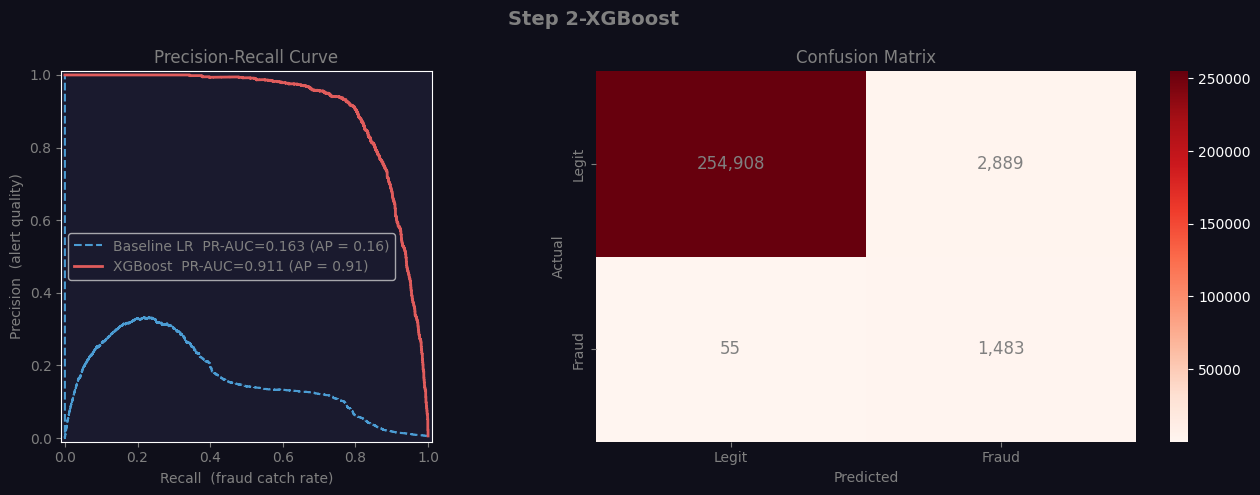

In [13]:
# ─────────────────────────────────────────────────────────────
# XGBoost Evaluation Plots
# ─────────────────────────────────────────────────────────────
# In this cell, I visualize how well the XGBoost model performs on the untouched test set.
#
# I use the same layout as the previous evaluation plots so the comparison stays consistent and easy to follow:
#   1) Precision-Recall Curve
#   2) Confusion Matrix
#
# I also include the Logistic Regression baseline curve so I can compare the improvement directly.

# Create a figure with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')

fig.suptitle(
    'Step 2-XGBoost',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Left Plot | Precision-Recall Curve
# ─────────────────────────────────────────────────────────────
# This plot shows the trade-off between:
#   - Recall    : how many fraud cases the model catches
#   - Precision : how reliable the fraud alerts are
#
# I plot both:
#   - Logistic Regression baseline
#   - XGBoost


# If the XGBoost curve is higher than the baseline curve, that means XGBoost gives a better balance between catching fraud and keeping false alerts lower.
ax = axes[0]
ax.set_facecolor('#1a1a2e')

# Baseline Logistic Regression curve for reference
PrecisionRecallDisplay.from_predictions(
    y_test,            # true labels from the test set
    y_prob_lr,         # fraud probabilities from Logistic Regression
    ax=ax,
    name=f'Baseline LR  PR-AUC={pr_auc_lr:.3f}',
    color=PALETTE['legit'],
    linestyle='--',
    linewidth=1.5
)

# XGBoost curve
PrecisionRecallDisplay.from_predictions(
    y_test,            # same true labels
    y_prob_xgb,        # fraud probabilities from XGBoost
    ax=ax,
    name=f'XGBoost  PR-AUC={pr_auc_xgb:.3f}',
    color=PALETTE['fraud'],
    linewidth=2
)

ax.set_title('Precision-Recall Curve', color='gray')
ax.set_xlabel('Recall  (fraud catch rate)', color='gray')
ax.set_ylabel('Precision  (alert quality)', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray')


# ─────────────────────────────────────────────────────────────
# Right Plot | Confusion Matrix
# ─────────────────────────────────────────────────────────────


ax = axes[1]
ax.set_facecolor('#1a1a2e')

# Build confusion matrix using the true labels and XGBoost predictions
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix as a heatmap
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt=',',
    cmap='Reds',
    ax=ax,
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud'],
    annot_kws={'size': 12, 'color': 'gray'}
)

ax.set_title('Confusion Matrix', color='gray')
ax.set_xlabel('Predicted', color='gray')
ax.set_ylabel('Actual', color='gray')
ax.tick_params(colors='gray')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / 'step2_xgboost.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

The XGBoost evaluation plots show a major improvement over the Logistic Regression baseline.

The Precision-Recall Curve for XGBoost is much higher than the baseline curve, and the PR-AUC increased from **0.163** to **0.911**. This means XGBoost provides a much stronger balance between catching fraud and keeping fraud alerts accurate.

The confusion matrix also confirms the improvement. XGBoost correctly detected **1,483 fraud transactions** out of **1,538** total fraud cases in the test set, missing only **55** fraud cases. It also reduced false fraud alerts to **2,889**, which is much lower than both Logistic Regression and Random Forest.



In [14]:
# ─────────────────────────────────────────────────────────────
# Model Comparison Summary Table
# ─────────────────────────────────────────────────────────────
# In this cell, I compare all trained models side by side.
#
# So far, I trained:
#   1) Logistic Regression as the baseline model
#   2) Random Forest using the SMOTE-resampled training data
#   3) XGBoost using scale_pos_weight for imbalance handling
#
# Now I want to compare them using the same test set.
# This keeps the comparison fair because every model is evaluated on the same real-world imbalanced test data.


# ─────────────────────────────────────────────────────────────
# Reusable metric helper function
# ─────────────────────────────────────────────────────────────
# This function calculates the main evaluation metrics for one model.
#
# I use a function here because the same calculations are needed for Logistic Regression, Random Forest, and XGBoost.
#
# Inputs:
#   y_true : actual test labels
#   y_pred : predicted class labels, 0 or 1
#   y_prob : predicted fraud probabilities
#   name   : model name to show in the comparison table

def fraud_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model': name,

        # Main metric for this project.
        # PR-AUC is better than accuracy for imbalanced fraud detection.
        'PR-AUC': round(average_precision_score(y_true, y_prob), 4),

        # Secondary metric.
        # ROC-AUC is useful, but it can look too optimistic when fraud is rare.
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4),

        # F2-score gives more weight to recall.
        # This matters because missing fraud is usually more costly.
        'F2-Score': round(fbeta_score(y_true, y_pred, beta=2), 4),

        # Precision tells me how many fraud alerts were truly fraud.
        # Higher precision means cleaner alerts and fewer false positives.
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),

        # Recall tells me how many actual fraud cases the model caught.
        # Higher recall means fewer missed fraud cases.
        'Recall': round(recall_score(y_true, y_pred), 4),
    }


# ─────────────────────────────────────────────────────────────
# Build the comparison table
# ─────────────────────────────────────────────────────────────
# Each row in this table represents one model.
# All metrics are calculated using the same y_test labels.

comparison = pd.DataFrame([
    fraud_metrics(
        y_test,
        y_pred_lr,
        y_prob_lr,
        'Logistic Regression (baseline)'
    ),

    fraud_metrics(
        y_test,
        y_pred_rf,
        y_prob_rf,
        'Random Forest + SMOTE'
    ),

    fraud_metrics(
        y_test,
        y_pred_xgb,
        y_prob_xgb,
        'XGBoost'
    ),
])

# Use model name as the table index to make the output easier to read.
comparison = comparison.set_index('Model')


# ─────────────────────────────────────────────────────────────
# Print the comparison table
# ─────────────────────────────────────────────────────────────
# This gives a clean side-by-side view of model performance.

line = '─' * 70

print(line)
print('  MODEL COMPARISON — test set with real-world imbalance')
print(line)
print(comparison.to_string())
print()


# ─────────────────────────────────────────────────────────────
# Select the best model by PR-AUC
# ─────────────────────────────────────────────────────────────
# PR-AUC is the main metric for this project, so I use it to choose the best model to carry forward into Step 3.

best_model_name = comparison['PR-AUC'].idxmax()
best_pr_auc = comparison['PR-AUC'].max()

print(f'  Best model by PR-AUC : {best_model_name}')
print(f'  PR-AUC               : {best_pr_auc:.4f}')

──────────────────────────────────────────────────────────────────────
  MODEL COMPARISON — test set with real-world imbalance
──────────────────────────────────────────────────────────────────────
                                PR-AUC  ROC-AUC  F2-Score  Precision  Recall
Model                                                                       
Logistic Regression (baseline)  0.1625   0.9182    0.2849     0.0802  0.7867
Random Forest + SMOTE           0.7173   0.9938    0.5991     0.2527  0.9116
XGBoost                         0.9105   0.9983    0.7046     0.3392  0.9642

  Best model by PR-AUC : XGBoost
  PR-AUC               : 0.9105



The model comparison table shows that XGBoost is the best-performing model in Step 2.

Logistic Regression was used as the baseline model and achieved a PR-AUC of **0.1625**. Random Forest with SMOTE improved the PR-AUC to **0.7173**, showing that a stronger tree-based model was much better at learning fraud patterns.

XGBoost achieved the best overall result with a PR-AUC of **0.9105**. It also had the highest F2-score, precision, and recall among the three models.

The XGBoost model achieved a fraud recall of **0.9642**, meaning it caught about 96% of fraud cases in the test set. It also had the best fraud precision at **0.3392**, meaning its fraud alerts were cleaner than the other models.

Based on PR-AUC, XGBoost will be selected as the best model and carried forward into Step 3 for threshold tuning.

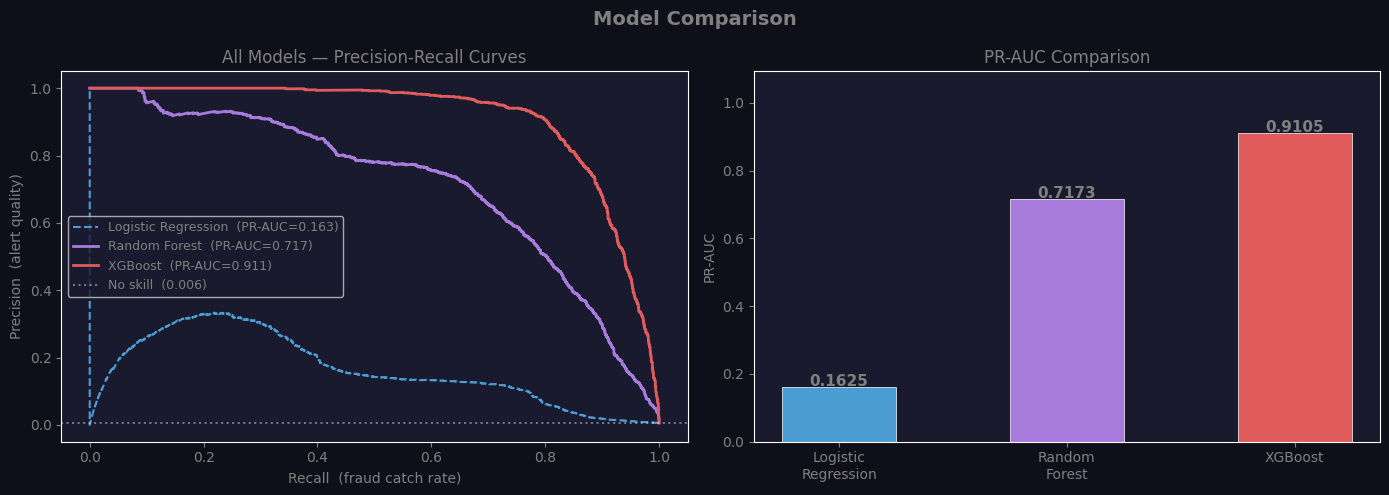

In [15]:
# ─────────────────────────────────────────────────────────────
# Model Comparison Plots
# ─────────────────────────────────────────────────────────────
# In this cell, I compare all three models visually so I can clearly identify the strongest one.
#
# I use two charts:
#   1) a combined Precision-Recall Curve for all models
#   2) a PR-AUC bar chart for a quick summary
#
# This helps me compare the models both visually and numerically.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')

fig.suptitle(
    'Model Comparison',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Left Plot | All Three Precision-Recall Curves
# ─────────────────────────────────────────────────────────────
# This chart overlays the PR curves of all models on the same axes.
#
# A curve that stays higher on the chart is better because it means the
# model is doing a better job balancing:
#   - Recall    : catching more fraud cases
#   - Precision : keeping fraud alerts cleaner
#
# I also add a no-skill baseline line. A random model would perform around the natural fraud rate in the test set.

ax = axes[0]
ax.set_facecolor('#1a1a2e')

models_to_plot = [
    ('Logistic Regression', y_prob_lr,  PALETTE['legit'],  '--', 1.5),
    ('Random Forest',       y_prob_rf,  PALETTE['accent'], '-',  2.0),
    ('XGBoost',             y_prob_xgb, PALETTE['fraud'],  '-',  2.0),
]

for name, probs, color, linestyle, linewidth in models_to_plot:
    # Build the precision-recall curve from the true test labels and the predicted fraud probabilities of each model.
    prec, rec, _ = precision_recall_curve(y_test, probs)

    # Calculate PR-AUC so I can show it directly in the legend.
    auc = average_precision_score(y_test, probs)

    ax.plot(
        rec,
        prec,
        label=f'{name}  (PR-AUC={auc:.3f})',
        color=color,
        linestyle=linestyle,
        linewidth=linewidth
    )

# A random classifier would perform close to the natural fraud rate.
# This gives a useful reference line for comparison.
no_skill = y_test.mean()

ax.axhline(
    y=no_skill,
    color='white',
    linestyle=':',
    alpha=0.4,
    label=f'No skill  ({no_skill:.3f})'
)

ax.set_title('All Models — Precision-Recall Curves', color='gray')
ax.set_xlabel('Recall  (fraud catch rate)', color='gray')
ax.set_ylabel('Precision  (alert quality)', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray', fontsize=9)


# ─────────────────────────────────────────────────────────────
# Right Plot | PR-AUC Bar Chart
# ─────────────────────────────────────────────────────────────
# This chart gives a simpler summary view of the main metric.
# Since PR-AUC is my most important metric for fraud detection, I compare the three PR-AUC values side by side.

ax = axes[1]
ax.set_facecolor('#1a1a2e')

# Use \n to split long labels across two lines
bar_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
bar_values = [pr_auc_lr, pr_auc_rf, pr_auc_xgb]
bar_colors = [PALETTE['legit'], PALETTE['accent'], PALETTE['fraud']]

bars = ax.bar(
    bar_names,
    bar_values,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.5
)

# Add the exact PR-AUC value above each bar
for bar, val in zip(bars, bar_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.4f}',
        ha='center',
        color='gray',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title('PR-AUC Comparison', color='gray')
ax.set_ylabel('PR-AUC', color='gray')
ax.tick_params(colors='gray')
ax.set_ylim(0, max(bar_values) * 1.2)


# ─────────────────────────────────────────────────────────────
# Save and show
# ─────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / 'step_model_comparison.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

The model comparison plots clearly show that XGBoost is the strongest model in Step 2.

The Precision-Recall Curve shows that XGBoost stays above both Logistic Regression and Random Forest across most recall levels. This means it provides the best balance between catching fraud cases and keeping fraud alerts accurate.

The PR-AUC bar chart confirms the same result. Logistic Regression achieved a PR-AUC of **0.1625**, Random Forest improved this to **0.7173**, and XGBoost achieved the highest PR-AUC of **0.9105**.

Because PR-AUC is the main metric for this imbalanced fraud detection problem, XGBoost will be selected as the best model and carried forward into Step 3 for threshold tuning.

In [16]:
# ─────────────────────────────────────────────────────────────
# Select Best Model
# ─────────────────────────────────────────────────────────────
# In this cell, I select the best model from Step 2.
#
# The comparison table already identified the best model using PR-AUC, which is the main metric for this imbalanced fraud detection project.
#
# I store the selected model, its fraud probabilities, and its predictions
# in shared variables:
#   best_model
#   best_probs
#   best_preds
#

_model_registry = {
    'Logistic Regression (baseline)': (baseline_pipe, y_prob_lr, y_pred_lr),
    'Random Forest + SMOTE': (rf_model, y_prob_rf, y_pred_rf),
    'XGBoost': (xgb_model, y_prob_xgb, y_pred_xgb),
}

# Select the model that had the highest PR-AUC in the comparison table.
best_model, best_probs, best_preds = _model_registry[best_model_name]


# ─────────────────────────────────────────────────────────────
# Confirm the selected model
# ─────────────────────────────────────────────────────────────
# This printout gives a clean summary of the selected model and how much it improved compared with the Logistic Regression baseline.

line = '─' * 50

print(line)
print('  Best Model Selected')
print(f'  Name     : {best_model_name}')
print(f'  PR-AUC   : {best_pr_auc:.4f}')
print(f'  Baseline : {pr_auc_lr:.4f}')
print(f'  Δ PR-AUC : {best_pr_auc - pr_auc_lr:+.4f}')
print(line)
print()


print(f'  PR-AUC benchmark going into Step 3: {best_pr_auc:.4f}')

──────────────────────────────────────────────────
  Best Model Selected
  Name     : XGBoost
  PR-AUC   : 0.9105
  Baseline : 0.1625
  Δ PR-AUC : +0.7480
──────────────────────────────────────────────────

  PR-AUC benchmark going into Step 3: 0.9105



In this step, I selected the best model from Step 2 using PR-AUC as the main metric.

XGBoost was selected as the best model because it achieved the highest PR-AUC score of **0.9105**, compared with the Logistic Regression baseline score of **0.1625**. This is an improvement of **+0.7480**.

I stored the selected model, its fraud probabilities, and its predictions in shared variables: `best_model`, `best_probs`, and `best_preds`. This makes the next steps easier because threshold tuning can use these shared variables directly.

# Step 3 - Threshold Tuning and Cost-Sensitive Evaluation

In Step 2, XGBoost was selected as the best model with a **PR-AUC of 0.9105**. Using the default threshold of **0.50**, the model already performed well: it caught **1,483 fraud cases out of 1,538**, giving it a fraud recall of **0.9642**.

However, the model also flagged **2,889 legitimate transactions** as fraud. This means the model is very good at catching fraud, but some of the fraud alerts are still false alerts. Those false alerts matter because someone would need to review them.

In Step 3, I will tune the prediction threshold instead of automatically accepting the default **0.50** cutoff. A threshold controls when a transaction is classified as fraud. For example, a lower threshold makes the model more sensitive and catches more possible fraud cases, but it may also create more false alerts. A higher threshold usually reduces false alerts, but it may miss more fraud.

Since fraud makes up less than **1%** of the transactions, the default threshold is not always the best business choice. The goal is to find a threshold that gives a better balance between catching fraud and keeping the number of false alerts reasonable.

I will also add a cost-sensitive evaluation by assigning dollar values to model errors. Missing a fraud transaction will be treated as a financial loss based on the average fraud amount. A false fraud alert will be treated as an investigation cost, estimated at **$25 CAD** per alert.

This step helps move the evaluation beyond model metrics only. Instead of asking only **Which threshold has the best score?**, I also want to ask: **Which threshold makes the most business sense?**

In [ ]:
# ─────────────────────────────────────────────────────────────
# Threshold Tuning
# ─────────────────────────────────────────────────────────────
# The selected model does not only predict 0 or 1. It also gives a fraud probability between 0 and 1 for every transaction.
#
# By default, many classifiers use a threshold of 0.50:
#   probability >= 0.50  : fraud
#   probability <  0.50  : legitimate
#
# However, in fraud detection, the default 0.50 threshold is not always the best business choice.
# Fraud is rare, and the cost of missing fraud can be higher than the cost of reviewing extra alerts.
#
# In this cell, I test many thresholds from 0.01 to 0.90.
# For each threshold, I calculate:
#   Precision : how many flagged fraud alerts were truly fraud
#   Recall    : how many real fraud cases the model caught
#   F2-Score  : a metric that gives more weight to recall
#
# I use F2-score because, in fraud detection, missing fraud is usually more expensive than reviewing a false alert.

import numpy as np

# Create a range of thresholds to test.
# 0.005 step gives a detailed scan without being too slow.
thresholds = np.arange(0.01, 0.90, 0.005)

# This list will store the result for each threshold.
results = []

for t in thresholds:
    # Convert fraud probabilities into final class predictions.
    # If the probability is greater than or equal to the threshold, the transaction is flagged as fraud.
    y_pred_t = (best_probs >= t).astype(int)

    # Calculate threshold-level metrics.
    # zero_division=0 prevents errors if a threshold creates no fraud alerts.
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f2 = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)

    # Count how many transactions were flagged as fraud at this threshold.
    alerts = int(y_pred_t.sum())

    # Save the result for this threshold.
    results.append({
        'threshold': t,
        'precision': prec,
        'recall': rec,
        'f2': f2,
        'alerts': alerts,
    })

# Convert the list of results into a DataFrame so it is easier to sort, filter, display, and plot.
threshold_df = pd.DataFrame(results)


# ─────────────────────────────────────────────────────────────
# Find the optimal threshold
# ─────────────────────────────────────────────────────────────
# The best threshold is the one with the highest F2-score.
# This gives priority to catching fraud while still considering precision.

best_row = threshold_df.loc[threshold_df['f2'].idxmax()]
BEST_THRESHOLD = best_row['threshold']


# ─────────────────────────────────────────────────────────────
# Print optimal threshold result
# ─────────────────────────────────────────────────────────────
# This shows the best threshold found by the scan and its performance.

line = '─' * 50

print(line)
print('  Optimal Threshold')
print(f'  Threshold  : {BEST_THRESHOLD:.3f}')
print(f'  F2-Score   : {best_row["f2"]:.4f}')
print(f'  Precision  : {best_row["precision"]:.4f}')
print(f'  Recall     : {best_row["recall"]:.4f}')
print(f'  Alerts     : {int(best_row["alerts"]):,}')
print(line)
print()


# ─────────────────────────────────────────────────────────────
# Compare default threshold vs tuned threshold
# ─────────────────────────────────────────────────────────────
# This comparison shows what changes when I move away from the default 0.50.
# The goal is to understand whether the tuned threshold catches more fraud,improves F2-score, or changes the number of alerts.

y_pred_default = (best_probs >= 0.50).astype(int)
y_pred_tuned = (best_probs >= BEST_THRESHOLD).astype(int)

print('─── Default (0.50) vs Tuned ─────────────────')

print(
    f'  Default :  '
    f'Recall: {recall_score(y_test, y_pred_default):.4f}   '
    f'Precision: {precision_score(y_test, y_pred_default, zero_division=0):.4f}   '
    f'F2: {fbeta_score(y_test, y_pred_default, beta=2, zero_division=0):.4f}   '
    f'Alerts: {y_pred_default.sum():,}'
)

print(
    f'  Tuned   :  '
    f'Recall: {recall_score(y_test, y_pred_tuned):.4f}   '
    f'Precision: {precision_score(y_test, y_pred_tuned, zero_division=0):.4f}   '
    f'F2: {fbeta_score(y_test, y_pred_tuned, beta=2, zero_division=0):.4f}   '
    f'Alerts: {y_pred_tuned.sum():,}'
)

──────────────────────────────────────────────────
  Optimal Threshold
  Threshold  : 0.890
  F2-Score   : 0.8475
  Precision  : 0.6951
  Recall     : 0.8966
  Alerts     : 1,984
──────────────────────────────────────────────────

─── Default (0.50) vs Tuned ─────────────────
  Default :  Recall: 0.9642   Precision: 0.3392   F2: 0.7046   Alerts: 4,372
  Tuned   :  Recall: 0.8966   Precision: 0.6951   F2: 0.8475   Alerts: 1,984


 The threshold tuning step selected **0.890** as the optimal threshold based on F2-score.

At the default threshold of **0.50**, the model achieved a recall of **0.9642**, precision of **0.3392**, and F2-score of **0.7046**. This means the model caught most fraud cases, but it also created a higher number of false alerts, with **4,372** transactions flagged as fraud.

After tuning, the threshold increased to **0.890**. At this threshold, recall decreased to **0.8966**, but precision increased strongly to **0.6951**. The number of fraud alerts dropped to **1,984**, which means the tuned threshold created a much smaller and cleaner review queue.

The F2-score improved from **0.7046** to **0.8475**, showing that the tuned threshold provides a better balance between catching fraud and keeping false alerts reasonable.

Overall, the tuned threshold makes the model more selective. It catches slightly fewer fraud cases, but the alerts are much more accurate and easier for a fraud review team to manage.

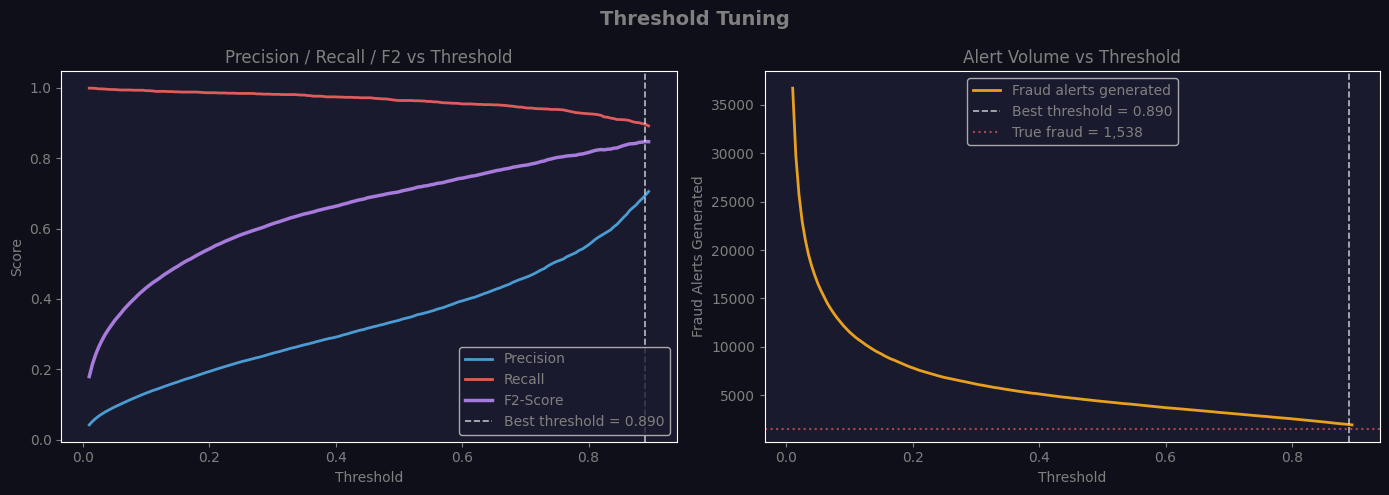

In [18]:
# ─────────────────────────────────────────────────────────────
# Threshold Tuning Plots
# ─────────────────────────────────────────────────────────────
# In this cell, I visualize how the model behaves as the fraud threshold changes.
#
# A threshold controls how strict the model is:
#   - lower threshold  : flags more transactions as fraud
#   - higher threshold : flags fewer transactions, but with more confidence
#
# I use two plots:
#   1) precision, recall, and F2-score at each threshold
#   2) number of fraud alerts generated at each threshold
#
# The dashed vertical line shows the best threshold selected earlier based on the highest F2-score.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')

fig.suptitle(
    'Threshold Tuning',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Left Plot | Precision, Recall, and F2-Score vs Threshold
# ─────────────────────────────────────────────────────────────
# This plot shows the trade-off caused by changing the threshold.
#
# Usually:
#   - lower thresholds increase recall because more fraud cases are caught
#   - lower thresholds reduce precision because more false alerts are created
#   - higher thresholds increase precision because alerts become more selective
#   - higher thresholds may reduce recall because some fraud cases are missed
#
# F2-score helps find a useful balance because it gives more weight to recall.

ax = axes[0]
ax.set_facecolor('#1a1a2e')

# Precision line: how clean the fraud alerts are
ax.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    color=PALETTE['legit'],
    linewidth=2,
    label='Precision'
)

# Recall line: how many real fraud cases are caught
ax.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    color=PALETTE['fraud'],
    linewidth=2,
    label='Recall'
)

# F2-score line: recall-weighted balance between precision and recall
ax.plot(
    threshold_df['threshold'],
    threshold_df['f2'],
    color=PALETTE['accent'],
    linewidth=2.5,
    label='F2-Score'
)

# Mark the selected best threshold
ax.axvline(
    x=BEST_THRESHOLD,
    color='white',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label=f'Best threshold = {BEST_THRESHOLD:.3f}'
)

ax.set_title('Precision / Recall / F2 vs Threshold', color='gray')
ax.set_xlabel('Threshold', color='gray')
ax.set_ylabel('Score', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray')


# ─────────────────────────────────────────────────────────────
# Right Plot | Alert Volume vs Threshold
# ─────────────────────────────────────────────────────────────
# This plot shows the business workload side of threshold tuning.
#
# If the threshold is low, the model sends many transactions for review.
# If the threshold is high, the model sends fewer alerts, but it may miss more fraud cases.
#
# The dotted horizontal line shows the real number of fraud cases in the test set, which gives a useful reference point.

ax = axes[1]
ax.set_facecolor('#1a1a2e')

# Number of transactions flagged as fraud at each threshold
ax.plot(
    threshold_df['threshold'],
    threshold_df['alerts'],
    color='#E8A020',
    linewidth=2,
    label='Fraud alerts generated'
)

# Mark the selected best threshold
ax.axvline(
    x=BEST_THRESHOLD,
    color='white',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label=f'Best threshold = {BEST_THRESHOLD:.3f}'
)

# Add a reference line for the actual number of fraud cases in the test set
true_fraud = int(y_test.sum())

ax.axhline(
    y=true_fraud,
    color=PALETTE['fraud'],
    linestyle=':',
    linewidth=1.5,
    alpha=0.7,
    label=f'True fraud = {true_fraud:,}'
)

ax.set_title('Alert Volume vs Threshold', color='gray')
ax.set_xlabel('Threshold', color='gray')
ax.set_ylabel('Fraud Alerts Generated', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────


plt.tight_layout()

plt.savefig(
    REPORTS_DIR / 'threshold_tuning.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

The threshold tuning plots show how the model behavior changes as the fraud threshold increases.

In the first chart, precision increases as the threshold becomes stricter, while recall slowly decreases. This makes sense because a higher threshold means the model only flags transactions when it is more confident. The F2-score improves as the threshold increases and reaches its best value at **0.890**.

In the second chart, the alert volume decreases sharply as the threshold increases. This shows the business impact of threshold tuning: a lower threshold creates too many fraud alerts, while a higher threshold creates a smaller and cleaner review queue.

At the tuned threshold of **0.890**, the model generates **1,984 fraud alerts**, compared with **1,538 actual fraud cases** in the test set. This is much more manageable than the default threshold and gives the fraud team a more focused set of transactions to review.



In [19]:
# ─────────────────────────────────────────────────────────────
# Cost-Sensitive Evaluation
# ─────────────────────────────────────────────────────────────
# In this cell, I turn the model errors into estimated dollar impact.
#
# Up to this point, I evaluated the model using ML metrics such as precision, recall, PR-AUC, and F2-score. 
# These are useful, but fraud detection is also a business problem.
#
# A threshold is not only better because it improves a metric. It is better if it also reduces financial loss or creates a more manageable review process.
#
# For this simple cost model, I use three assumptions:
#
#   False Negative (FN):
#     A fraud transaction was missed by the model.
#     Cost = average fraud transaction amount, because the fraud was not stopped.
#
#   False Positive (FP):
#     A legitimate transaction was flagged as fraud.
#     Cost = analyst review time, estimated at $25 CAD per alert.
#
#   True Positive (TP):
#     A fraud transaction was correctly caught.
#     Saving = average fraud transaction amount, because the fraud was prevented.
#
# This helps compare the default threshold against the tuned threshold in business terms, not just model scores.


# ─────────────────────────────────────────────────────────────
# Calculate average fraud transaction amount
# ─────────────────────────────────────────────────────────────
# I calculate the average fraud amount using the test set only.
#
# X_test contains the selected model features, including amount_cad.
# y_test tells me which rows are actual fraud transactions.
#
# By filtering X_test where y_test == 1, I get only the actual fraud transactions from the test period.

fraud_mask = y_test == 1
avg_fraud_amt = X_test.loc[fraud_mask, 'amount_cad'].mean()

print('─── Cost Model ──────────────────────────────')
print(f'  Avg fraud transaction  : ${avg_fraud_amt:,.2f} CAD')
print(f'  False Negative cost    : ${avg_fraud_amt:,.2f}  (missed fraud - full amount lost)')
print(f'  False Positive cost    : $25.00             (analyst review per alert)')
print(f'  True Positive saving   : ${avg_fraud_amt:,.2f}  (fraud caught - amount saved)')
print()


# ─────────────────────────────────────────────────────────────
# Define cost assumptions
# ─────────────────────────────────────────────────────────────
# These values will be used in the business_cost() function below.
#
# COST_FN:
#   cost of missing one fraud transaction
#
# COST_FP:
#   cost of reviewing one false fraud alert
#
# SAVING_TP:
#   estimated money saved when one fraud transaction is caught

COST_FN = avg_fraud_amt
COST_FP = 25.0
SAVING_TP = avg_fraud_amt


# ─────────────────────────────────────────────────────────────
# Business cost helper function
# ─────────────────────────────────────────────────────────────
# This function calculates business cost for one set of predictions.
#
# It starts with the confusion matrix:
#   TN = legitimate correctly predicted as legitimate
#   FP = legitimate incorrectly flagged as fraud
#   FN = fraud incorrectly missed
#   TP = fraud correctly detected
#
# Then it estimates:
#   - cost from missed fraud
#   - cost from false alerts
#   - savings from caught fraud
#   - final net benefit

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    cost_fn = fn * COST_FN
    cost_fp = fp * COST_FP

    total_cost = cost_fn + cost_fp
    total_saving = tp * SAVING_TP

    net_benefit = total_saving - total_cost

    return {
        'TP': int(tp),
        'FP': int(fp),
        'FN': int(fn),
        'TN': int(tn),
        'Cost (FN)': cost_fn,
        'Cost (FP)': cost_fp,
        'Total Cost': total_cost,
        'Total Saving': total_saving,
        'Net Benefit': net_benefit,
    }


# ─────────────────────────────────────────────────────────────
# Compare default threshold vs tuned threshold
# ─────────────────────────────────────────────────────────────
# y_pred_default uses the original 0.50 threshold.
# y_pred_tuned uses the best threshold found earlier using F2-score.
#
# This comparison shows whether threshold tuning improved the estimated
# business value of the model.

cost_default = business_cost(y_test, y_pred_default)
cost_tuned = business_cost(y_test, y_pred_tuned)


# ─────────────────────────────────────────────────────────────
# Print default threshold cost summary
# ─────────────────────────────────────────────────────────────

line = '─' * 50

print(f'{line}')
print('  Default Threshold (0.50)')
print(f'{line}')

for k, v in cost_default.items():
    if isinstance(v, float):
        print(f'  {k:<18} : ${v:>12,.2f} CAD')
    else:
        print(f'  {k:<18} : {v:>12,}')


# ─────────────────────────────────────────────────────────────
# Print tuned threshold cost summary
# ─────────────────────────────────────────────────────────────

print()
print(f'{line}')
print(f'  Tuned Threshold ({BEST_THRESHOLD:.3f})')
print(f'{line}')

for k, v in cost_tuned.items():
    if isinstance(v, float):
        print(f'  {k:<18} : ${v:>12,.2f} CAD')
    else:
        print(f'  {k:<18} : {v:>12,}')


# ─────────────────────────────────────────────────────────────
# Calculate net improvement
# ─────────────────────────────────────────────────────────────
# Positive value means the tuned threshold has a better estimated net benefit than the default threshold.

print()

improvement = cost_tuned['Net Benefit'] - cost_default['Net Benefit']

print(f'  Net improvement from tuning : ${improvement:,.2f} CAD')

─── Cost Model ──────────────────────────────
  Avg fraud transaction  : $727.10 CAD
  False Negative cost    : $727.10  (missed fraud - full amount lost)
  False Positive cost    : $25.00             (analyst review per alert)
  True Positive saving   : $727.10  (fraud caught - amount saved)

──────────────────────────────────────────────────
  Default Threshold (0.50)
──────────────────────────────────────────────────
  TP                 :        1,483
  FP                 :        2,889
  FN                 :           55
  TN                 :      254,908
  Cost (FN)          : $   39,990.68 CAD
  Cost (FP)          : $   72,225.00 CAD
  Total Cost         : $  112,215.68 CAD
  Total Saving       : $1,078,294.09 CAD
  Net Benefit        : $  966,078.41 CAD

──────────────────────────────────────────────────
  Tuned Threshold (0.890)
──────────────────────────────────────────────────
  TP                 :        1,379
  FP                 :          605
  FN                 :    

The cost-sensitive evaluation shows an important difference between model metrics and business value.

The tuned threshold of **0.890** improved the F2-score and reduced false positives from **2,889** to **605**, which means it created a much smaller and cleaner fraud review queue.

However, the tuned threshold also increased false negatives from **55** to **159**. This means the model missed **104 more fraud transactions** compared with the default threshold.

Because each missed fraud transaction is estimated to cost **$727.10 CAD**, the additional missed fraud cases outweighed the savings from reducing false alerts.

At the default threshold of **0.50**, the estimated net benefit was **$966,078.41 CAD**. At the tuned threshold of **0.890**, the estimated net benefit was **$871,940.94 CAD**. This means threshold tuning reduced the estimated net benefit by **$94,137.47 CAD** under the current cost assumptions.

This shows that the threshold with the best F2-score is not always the best business threshold. Based on the current cost model, the default threshold provides better financial value, while the tuned threshold provides a cleaner and smaller review queue.

0.50 : best financial net benefit

0.890: best F2-score and cleaner alerts

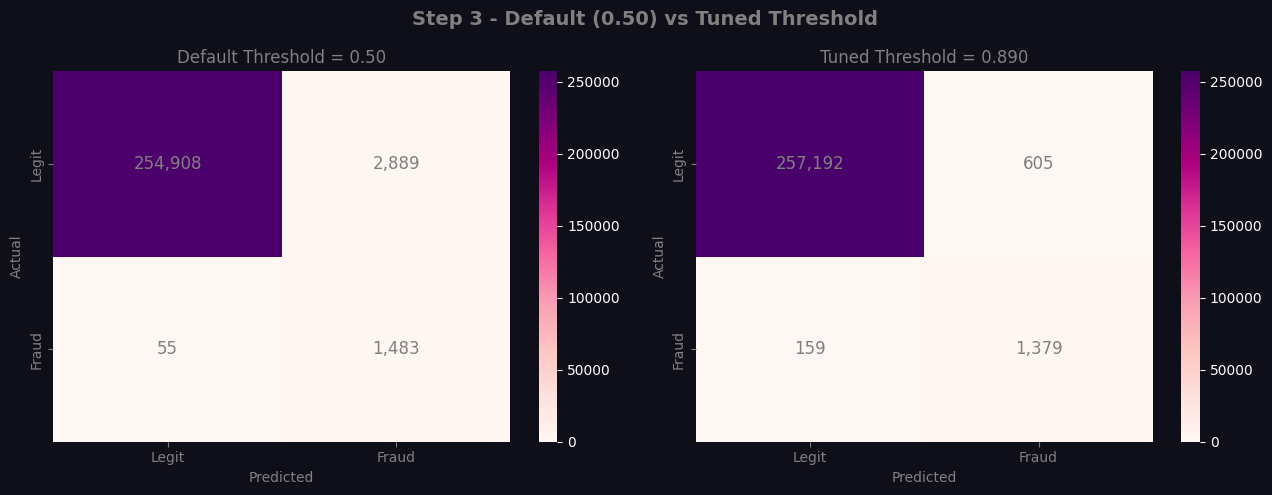

──────────────────────────────────────────────────
  Threshold Change Summary
  Default threshold  : 0.50
  Tuned threshold    : 0.890
──────────────────────────────────────────────────
  Change in fraud caught (TP)       : -104
  Change in false alerts (FP)       : -2,284
  Change in missed fraud (FN)       : +104
──────────────────────────────────────────────────

  Interpretation:
  The tuned threshold creates fewer false alerts,
  but it also catches fewer fraud cases and misses more fraud.

  BEST_THRESHOLD = 0.890 saved for next steps


In [20]:
# ─────────────────────────────────────────────────────────────
# Default vs Tuned Confusion Matrices
# ─────────────────────────────────────────────────────────────
# In this cell, I compare the confusion matrices for two thresholds:
#
#   1) Default threshold = 0.50
#   2) Tuned threshold   = BEST_THRESHOLD
#
# This makes the threshold trade-off easier to understand in real counts.
#
# The default threshold catches more fraud, but it also creates more false alerts.
# The tuned threshold creates a cleaner review queue, but it misses more fraud.
#
# This comparison helps me decide whether the tuned threshold is worth the business trade-off.

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0f0f1a')

fig.suptitle(
    'Step 3 - Default (0.50) vs Tuned Threshold',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Build confusion matrices
# ─────────────────────────────────────────────────────────────
# cm_default shows results at the original 0.50 threshold.
# cm_tuned shows results at the threshold selected by F2-score.

cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Use the same color scale for both heatmaps.
# This keeps the visual comparison fair because both charts use the same range.
vmax = max(cm_default.max(), cm_tuned.max())


# ─────────────────────────────────────────────────────────────
# Plot both confusion matrices
# ─────────────────────────────────────────────────────────────
# Layout:
#   rows    = actual class
#   columns = predicted class
#
# Top-left     = true legitimate transactions
# Top-right    = false fraud alerts
# Bottom-left  = missed fraud
# Bottom-right = correctly detected fraud

for ax, cm, title in [
    (axes[0], cm_default, 'Default Threshold = 0.50'),
    (axes[1], cm_tuned, f'Tuned Threshold = {BEST_THRESHOLD:.3f}'),
]:
    ax.set_facecolor('#1a1a2e')

    sns.heatmap(
        cm,
        annot=True,
        fmt=',',
        cmap='RdPu',
        ax=ax,
        vmin=0,
        vmax=vmax,
        xticklabels=['Legit', 'Fraud'],
        yticklabels=['Legit', 'Fraud'],
        annot_kws={'size': 12, 'color': 'gray'}
    )

    ax.set_title(title, color='gray')
    ax.set_xlabel('Predicted', color='gray')
    ax.set_ylabel('Actual', color='gray')
    ax.tick_params(colors='gray')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────


plt.tight_layout()

plt.savefig(
    REPORTS_DIR / 'step_confusion_matrices.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()


# ─────────────────────────────────────────────────────────────
# Print threshold change summary
# ─────────────────────────────────────────────────────────────
# These values show how the tuned threshold changed the model behavior.
#
# Positive / negative signs are kept so the direction of change is clear.

tp_change = cost_tuned['TP'] - cost_default['TP']
fp_change = cost_tuned['FP'] - cost_default['FP']
fn_change = cost_tuned['FN'] - cost_default['FN']

line = '─' * 50

print(line)
print('  Threshold Change Summary')
print(f'  Default threshold  : 0.50')
print(f'  Tuned threshold    : {BEST_THRESHOLD:.3f}')
print(line)

print(f'  Change in fraud caught (TP)       : {tp_change:+,}')
print(f'  Change in false alerts (FP)       : {fp_change:+,}')
print(f'  Change in missed fraud (FN)       : {fn_change:+,}')

print(line)
print()

print('  Interpretation:')
print('  The tuned threshold creates fewer false alerts,')
print('  but it also catches fewer fraud cases and misses more fraud.')
print()
print(f'  BEST_THRESHOLD = {BEST_THRESHOLD:.3f} saved for next steps')

In [21]:
# ─────────────────────────────────────────────────────────────
# Final Threshold Decision
# ─────────────────────────────────────────────────────────────
# Two thresholds were evaluated in Step 3:
#
#   BEST_THRESHOLD = 0.890 : highest F2-score, cleanest alert queue
#   Default        = 0.50  : highest net financial benefit
#
# For Step 4 (SHAP) and Step 5 (SQL Server predictions), I will use the financially optimal threshold because this project is business-driven.
# The goal is to maximise money recovered from fraud, not just score quality.

FINAL_THRESHOLD = 0.50   

print(f'  FINAL_THRESHOLD = {FINAL_THRESHOLD}')
print(f'  This will be used in Step 4 and Step 5.')

  FINAL_THRESHOLD = 0.5
  This will be used in Step 4 and Step 5.


# Step 4 - SHAP Explainability

In Step 2, XGBoost was selected as the best model with a **PR-AUC of 0.9105**. In Step 3, I tested different thresholds and used a cost-sensitive evaluation to compare the business impact. Based on that cost analysis, the **default threshold of 0.50** gave the best financial net benefit of **$966,078.41 CAD**.

So far, the project has answered an important question:

**How well does the model perform?**

The answer is that XGBoost performs very well at detecting fraud. However, performance metrics alone are not enough for a fraud detection system. A fraud analyst, manager, or compliance reviewer also needs to understand **why** the model made a specific decision.

That is the purpose of Step 4.

In this step, I will use **SHAP** to explain the model’s predictions. SHAP stands for **SHapley Additive exPlanations**. In simple terms, SHAP shows how each feature influenced the model’s prediction.

For example, if the model flags a transaction as fraud, SHAP can help explain whether that decision was mainly influenced by the transaction amount, distance, time of day, transaction category, customer location, or another feature.

A **positive SHAP value** means the feature pushed the prediction more toward fraud.  
A **negative SHAP value** means the feature pushed the prediction more toward legitimate.

This is important because XGBoost is a powerful model, but it is not easy to explain by looking at the model directly. It is made up of many decision trees working together, so without SHAP, the model can feel like a black box.

In Step 4, I will create three main explainability outputs:

- A **beeswarm plot** that shows how each feature affects fraud predictions across many transactions
- A **feature importance bar chart** that ranks the most influential features overall
- A **waterfall plot** that explains one high-risk transaction step by step

These outputs will help connect the machine learning model to real business understanding. Instead of only saying “the model flagged this transaction,” I will be able to explain **what made the transaction look suspicious**.

In [22]:
# ─────────────────────────────────────────────────────────────
# SHAP Setup : Explainer and Sample
# ─────────────────────────────────────────────────────────────
# In this cell, I prepare the data needed for SHAP explainability.
#
# SHAP calculates one explanation value for every feature in every transaction.
# Since the full test set has 259,335 rows, running SHAP on the full test set would be slow and memory-heavy.
#
# To keep the explanation step practical, I create a smaller sample:
#   - all fraud rows from the test set
#   - a random sample of legitimate rows
#
# This keeps all real fraud examples in the explanation sample while still including enough legitimate transactions for comparison.
#
# Since the selected best model is XGBoost, I use TreeExplainer.
# TreeExplainer is designed for tree-based models and is much faster than KernelExplainer for this type of model.

print('Building SHAP sample...')


# ─────────────────────────────────────────────────────────────
# Build the SHAP sample
# ─────────────────────────────────────────────────────────────
# Keep all actual fraud transactions from the test set.
# These are the most important cases to explain because they show the patterns the model uses to identify fraud.
fraud_rows = X_test[y_test == 1]

# Take a random sample of legitimate transactions.
# This gives the explainer enough normal transactions for comparison without making SHAP too slow.
legit_sample_size = min(3000, (y_test == 0).sum())

legit_rows = X_test[y_test == 0].sample(
    n=legit_sample_size,
    random_state=SEED
)

# Combine fraud and legitimate rows into one SHAP sample.
# sort_index keeps the rows in their original test-set order.
X_shap = pd.concat([fraud_rows, legit_rows]).sort_index()

# Keep the matching labels for the SHAP sample.
# This is useful later if I want to compare explanations for fraud vs legit.
y_shap = y_test.loc[X_shap.index]


print(f'  Fraud rows   : {(y_shap == 1).sum():,}')
print(f'  Legit rows   : {(y_shap == 0).sum():,}')
print(f'  Total sample : {len(X_shap):,}')
print()



# ─────────────────────────────────────────────────────────────
# Compute SHAP values using XGBoost native pred_contribs
# ─────────────────────────────────────────────────────────────
# Because XGBoost 3.x has a compatibility issue with shap.TreeExplainer,I use XGBoost's native SHAP contribution method instead.
#
# pred_contribs=True returns SHAP-style contribution values directly from the XGBoost booster.
#
# The returned array includes one extra last column called the bias/base value.
# I remove that last column so shap_vals only contains feature-level SHAP values.

print('Computing SHAP values using XGBoost native pred_contribs...')
print()

booster = best_model.get_booster()

dmat_shap = xgb.DMatrix(
    X_shap,
    feature_names=list(X_shap.columns)
)

shap_contribs = booster.predict(
    dmat_shap,
    pred_contribs=True
)

# Last column is the model bias/base value, not a feature.
shap_vals = shap_contribs[:, :-1]
shap_base_value = shap_contribs[:, -1]

print(f'  SHAP contribs shape : {shap_contribs.shape}')
print(f'  SHAP values shape   : {shap_vals.shape}')
print(f'  Features            : {X_shap.shape[1]}')
print(f'  Transactions        : {X_shap.shape[0]:,}')
print()
print('  SHAP computation complete')

Building SHAP sample...
  Fraud rows   : 1,538
  Legit rows   : 3,000
  Total sample : 4,538

Computing SHAP values using XGBoost native pred_contribs...

  SHAP contribs shape : (4538, 16)
  SHAP values shape   : (4538, 15)
  Features            : 15
  Transactions        : 4,538

  SHAP computation complete


The SHAP sample was created successfully using all fraud transactions from the test set and a random sample of 3,000 legitimate transactions. This produced a total explainability sample of **4,538 transactions**.

Because of a compatibility issue between the installed XGBoost and SHAP versions, I used XGBoost’s native `pred_contribs=True` method instead of `TreeExplainer`. This still returns SHAP-style feature contribution values directly from the XGBoost booster.

The returned SHAP contribution array had 16 columns: 15 feature contribution columns plus one final base/bias column. I removed the final bias column so `shap_vals` contains only the feature-level SHAP impacts.

The final SHAP values matrix has a shape of **4,538 × 15**, meaning each transaction now has one explanation value for each of the 15 model features.

Generating beeswarm plot...


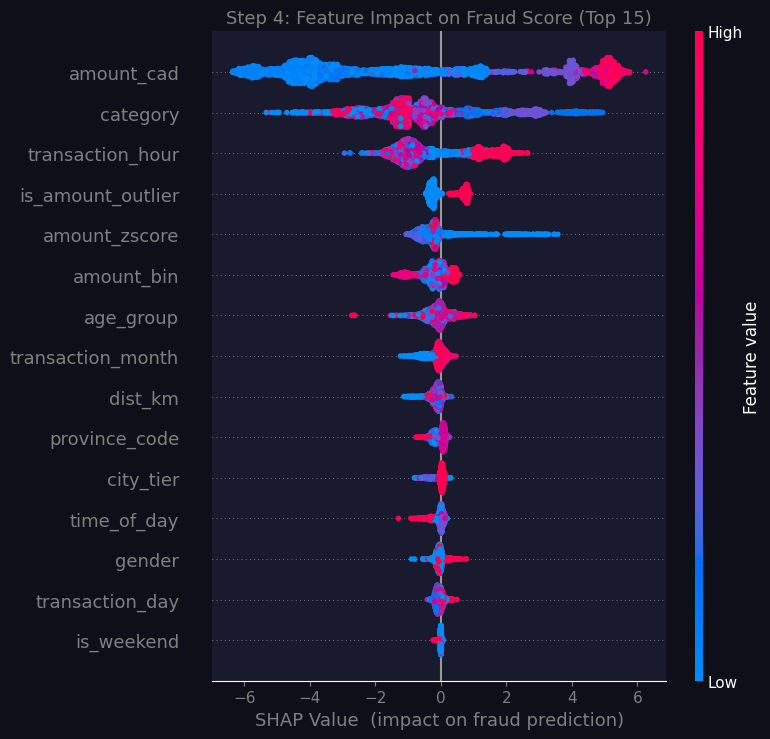

  Saved: step4a_shap_summary.png


In [23]:
# ─────────────────────────────────────────────────────────────
# Step 4a | SHAP Beeswarm Summary Plot
# ─────────────────────────────────────────────────────────────
# In this cell, I create the SHAP beeswarm summary plot.
#
# This is one of the most useful SHAP visualizations because it gives a population-level view of how the model behaves across many transactions.
#
# What this plot shows:
#   - each dot represents one transaction
#   - each row represents one feature
#   - the x-axis shows the SHAP value, which is the impact of that feature on the model output
#
# Interpretation:
#   positive SHAP value : pushed the prediction more toward fraud
#   negative SHAP value : pushed the prediction more toward legitimate
#
# Dot color:
#   red  : high feature value
#   blue : low feature value
#
# Features are ranked from top to bottom based on their average absolute SHAP impact, so the most important features appear first.

print('Generating beeswarm plot...')


plt.figure(figsize=(11, 7), facecolor='#0f0f1a')

# Generate the SHAP summary plot.
# shap_vals : SHAP contribution values (one row per transaction, one column per feature)
# X_shap    : the sampled transactions used to calculate SHAP
# plot_type='dot' creates the beeswarm version of the summary plot
# max_display=15 shows the top 15 most important features
# show=False keeps the plot open so I can restyle it before displaying
shap.summary_plot(
    shap_vals,
    X_shap,
    plot_type='dot',
    max_display=15,
    show=False
)

# Access the current figure created by SHAP so I can apply my notebook styling.
fig = plt.gcf()
fig.set_facecolor('#0f0f1a')

fig.axes[0].set_facecolor('#1a1a2e')
fig.axes[0].tick_params(colors='gray')
fig.axes[0].set_xlabel('SHAP Value  (impact on fraud prediction)', color='gray')
fig.axes[0].title.set_color('gray')

plt.title(
    'Step 4: Feature Impact on Fraud Score (Top 15)',
    color='gray',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / 'step4_shap_summary.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

print('  Saved: step4a_shap_summary.png')

The SHAP beeswarm plot shows which features have the strongest impact on the XGBoost fraud predictions.

The most influential feature is `amount_cad`, which means the transaction amount is the strongest driver of the model’s fraud score. Higher transaction amounts tend to push predictions toward fraud, while lower transaction amounts often push predictions toward legitimate.

Other important features include `category`, `transaction_hour`, `is_amount_outlier`, `amount_zscore`, and `amount_bin`. This suggests that the model relies heavily on transaction amount behavior, transaction type, and time-based patterns when identifying suspicious activity.

The `is_amount_outlier` feature is especially useful because higher values push the model toward fraud, meaning unusually large transactions are treated as stronger fraud signals.

For encoded categorical features such as `category`, `province_code`, `transaction_month`, and `age_group`, the color scale represents encoded numeric values rather than the original category names. These features are still important, but exact category-level interpretation should be decoded using the saved label encoders.



─── Top 15 Features by Mean |SHAP| ──────────────
          feature  mean_abs_shap
       amount_cad         3.5319
         category         1.4267
 transaction_hour         1.0819
is_amount_outlier         0.3984
    amount_zscore         0.3972
       amount_bin         0.3038
        age_group         0.2485
transaction_month         0.1812
          dist_km         0.1515
    province_code         0.1336
        city_tier         0.1010
      time_of_day         0.0954
           gender         0.0897
  transaction_day         0.0896
       is_weekend         0.0179



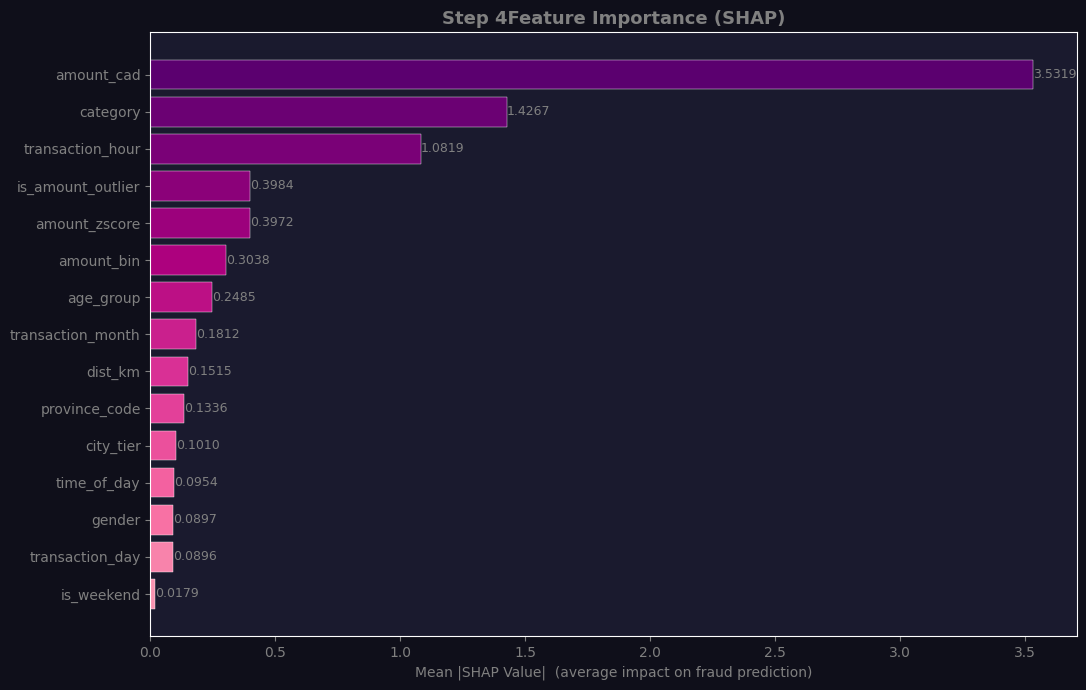

  Saved : step4_shap_importance.png
  Saved : ..\data\processed\ml_shap_importance.csv  (Power BI export)


In [45]:
# ─────────────────────────────────────────────────────────────
# Step 4b | SHAP Feature Importance Bar Chart
# ─────────────────────────────────────────────────────────────
# In the previous SHAP beeswarm plot, I looked at both direction and spread: which features push predictions toward fraud or toward legitimate.
#
# In this cell, I create a simpler feature importance chart.
#Instead of looking at positive and negative SHAP values separately, I use the mean absolute SHAP value for each feature.
#
# This means:
#   - I ignore whether the feature pushed toward fraud or legitimate
#   - I only measure how strongly the feature influenced predictions overall
#
# A higher mean absolute SHAP value means the feature had a stronger average impact on the model's fraud predictions.
#


# ─────────────────────────────────────────────────────────────
# Calculate mean absolute SHAP value per feature
# ─────────────────────────────────────────────────────────────
# shap_vals contains one SHAP value per feature per transaction.
# np.abs(shap_vals) removes the direction and keeps only the size of the impact.
# mean(axis=0) averages the impact for each feature across all SHAP sample rows.

shap_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values(
    'mean_abs_shap',
    ascending=False
).reset_index(drop=True)


# Print the top 15 most important features.
# This gives a quick text version before creating the chart.
print('─── Top 15 Features by Mean |SHAP| ──────────────')
print(shap_importance.head(15).to_string(index=False))
print()


# ─────────────────────────────────────────────────────────────
# Plot the feature importance bar chart
# ─────────────────────────────────────────────────────────────
# I only plot the top 15 features so the chart stays readable.

top15 = shap_importance.head(15)

fig, ax = plt.subplots(figsize=(11, 7), facecolor='#0f0f1a')
ax.set_facecolor('#1a1a2e')

# Create a soft gradient so the bars are visually ranked.
bar_colors = plt.cm.RdPu(np.linspace(0.4, 0.95, len(top15)))

# Reverse the order in the plot so the most important feature appears at the top.
bars = ax.barh(
    top15['feature'][::-1],
    top15['mean_abs_shap'][::-1],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.3
)

# Add the exact SHAP importance value at the end of each bar.
for bar, val in zip(bars, top15['mean_abs_shap'][::-1]):
    ax.text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center',
        color='gray',
        fontsize=9
    )

ax.set_xlabel(
    'Mean |SHAP Value|  (average impact on fraud prediction)',
    color='gray'
)

ax.set_title(
    'Step 4Feature Importance (SHAP)',
    color='gray',
    fontsize=13,
    fontweight='bold'
)

ax.tick_params(colors='gray')

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / 'step4_shap_importance.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()


# ─────────────────────────────────────────────────────────────
# Save as CSV for Power BI
# ─────────────────────────────────────────────────────────────
# This file can be loaded into Power BI as a feature importance table/chart.
# It contains every feature ranked by its average SHAP impact.

pbi_path = ROOT / 'data' / 'processed' / 'ml_shap_importance.csv'

pbi_path.parent.mkdir(parents=True, exist_ok=True)

# Normalize mean_abs_shap to 0-1 range for Power BI
# The raw pred_contribs values are in log-odds scale so they need to be normalized before they make sense as a ranked importance chart
shap_importance_pbi = shap_importance.copy()
shap_importance_pbi['mean_abs_shap'] = (
    shap_importance_pbi['mean_abs_shap'] /
    shap_importance_pbi['mean_abs_shap'].sum()
)

shap_importance_pbi.to_csv(pbi_path, index=False)

print(f'  Saved : step4_shap_importance.png')
print(f'  Saved : {pbi_path}  (Power BI export)')


The SHAP feature importance chart shows that `amount_cad` is the strongest driver of the XGBoost model’s fraud predictions. Its average SHAP impact is much higher than all other features, which means transaction amount has the largest influence on the model output.

The next most important features are `category` and `transaction_hour`, showing that transaction type and time of day also play major roles in fraud detection.

Several amount-related features also appear near the top, including `is_amount_outlier`, `amount_zscore`, and `amount_bin`. This confirms that the model relies heavily on both the actual transaction amount and how unusual that amount is compared with normal transaction behavior.

This chart is useful for reporting because it gives a simple ranked view of the most influential features. However, it only shows the strength of each feature’s impact, not the direction. To understand whether a feature pushes predictions toward fraud or legitimate, the beeswarm plot should be used.

The feature importance table was also exported to `ml_shap_importance.csv` so it can be loaded into Power BI for the model explainability page.

─── High-Risk Transaction Selected ─────────────
  Row position in SHAP sample : 4117
  Original row index          : 1275589
  Predicted probability       : 0.9999
  Actual label                : 1  (1 = fraud, 0 = legit)

─── Feature Values ──────────────────────────────
  category             value:          4.0   SHAP: +2.9440   up- fraud
  gender               value:          1.0   SHAP: +0.0093   up- fraud
  province_code        value:          3.0   SHAP: -0.0132   down- legit
  city_tier            value:          3.0   SHAP: -0.0034   down- legit
  dist_km              value:       319.32   SHAP: -0.0036   down- legit
  amount_cad           value:       400.01   SHAP: +3.8946   up- fraud
  transaction_hour     value:          1.0   SHAP: -0.6276   down- legit
  transaction_day      value:          3.0   SHAP: -0.0799   down- legit
  transaction_month    value:          6.0   SHAP: -0.1836   down- legit
  is_weekend           value:          1.0   SHAP: -0.0936   down- legit
  

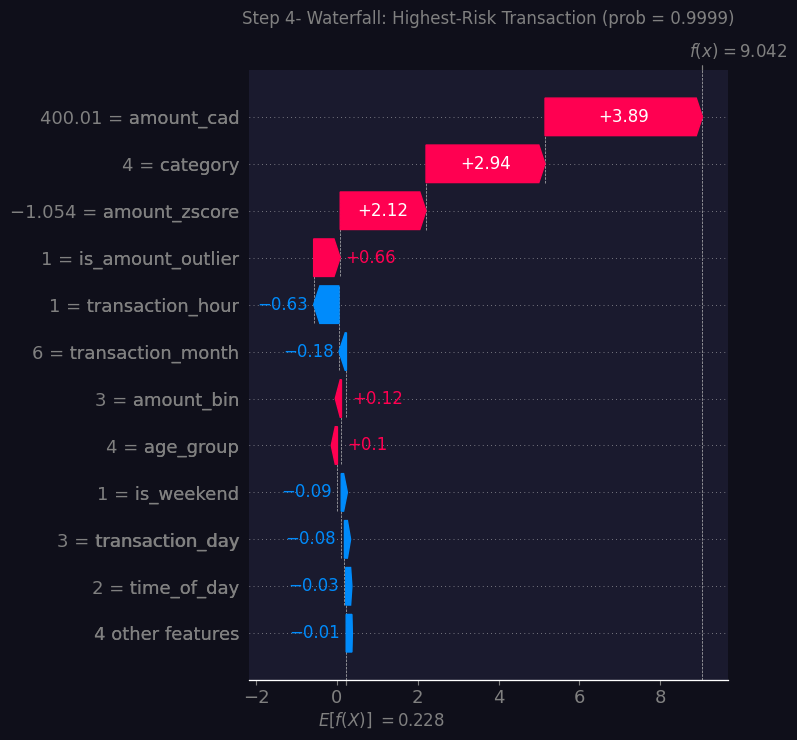

  Saved : step4_shap_waterfall.png


In [25]:
# ─────────────────────────────────────────────────────────────
# Step 4c | SHAP Waterfall —-Explaining One High-Risk Transaction
# ─────────────────────────────────────────────────────────────
# The beeswarm plot and feature importance chart showed the model behavior across many transactions.
#
# In this cell, I switch from the population view to one specific case.
# I explain a single high-risk transaction in detail using a waterfall plot.
#
# I choose the transaction in the SHAP sample with the highest predictedfraud probability.
# This is the case the model is most confident about, so it should give a clear explanation of what pushed the prediction up.
#
# How to read the waterfall plot:
#   Base value   : the model's starting point before seeing this transaction
#   Red bars     : features that pushed the prediction more toward fraud
#   Blue bars    : features that pushed the prediction more toward legitimate
#   Final output : the model output after combining all feature contributions
#
# Note:
# The displayed waterfall contributions are on the model output / score scale.
# For readability, I still show the predicted fraud probability in the title.

# ─────────────────────────────────────────────────────────────
# Find the highest-risk transaction in the SHAP sample
# ─────────────────────────────────────────────────────────────
# predict_proba gives the fraud probability for each row in X_shap.
# I use this only to choose the transaction to explain.
shap_probs = best_model.predict_proba(X_shap)[:, 1]

# Position of the transaction with the highest fraud probability
top_pos = int(np.argmax(shap_probs))

# Useful details for interpretation
top_prob = shap_probs[top_pos]
top_label = int(y_shap.iloc[top_pos])
top_index = X_shap.index[top_pos]

print('─── High-Risk Transaction Selected ─────────────')
print(f'  Row position in SHAP sample : {top_pos}')
print(f'  Original row index          : {top_index}')
print(f'  Predicted probability       : {top_prob:.4f}')
print(f'  Actual label                : {top_label}  (1 = fraud, 0 = legit)')
print()


# ─────────────────────────────────────────────────────────────
# Print feature values for this transaction
# ─────────────────────────────────────────────────────────────
# This helps me read the waterfall plot more clearly by showing the original feature values alongside their SHAP contributions.
print('─── Feature Values ──────────────────────────────')

transaction = X_shap.iloc[top_pos]

for feat, val in transaction.items():
    feat_idx = X_shap.columns.get_loc(feat)
    shap_score = shap_vals[top_pos, feat_idx]
    direction = 'up- fraud' if shap_score > 0 else 'down- legit'
    print(
        f'  {feat:<20} value: {str(val):>12}   '
        f'SHAP: {shap_score:+.4f}   {direction}'
    )

print()


# ─────────────────────────────────────────────────────────────
# Build a SHAP Explanation object manually
# ─────────────────────────────────────────────────────────────
# Because I used XGBoost native pred_contribs earlier (instead of shap.TreeExplainer), I manually construct a SHAP Explanation object for this one transaction.
#
# values      : SHAP contributions for this transaction
# base_values : model base value / bias term for this transaction
# data        : original feature values
# feature_names : column names used by the model

waterfall_exp = shap.Explanation(
    values=shap_vals[top_pos],
    base_values=shap_base_value[top_pos],
    data=transaction.values,
    feature_names=X_shap.columns.tolist()
)


# ─────────────────────────────────────────────────────────────
# Plot the waterfall
# ─────────────────────────────────────────────────────────────
print('Generating waterfall plot...')

plt.figure(figsize=(11, 7), facecolor='#0f0f1a')

shap.plots.waterfall(
    waterfall_exp,
    max_display=12,
    show=False
)

# Apply dark theme styling
fig = plt.gcf()
fig.set_facecolor('#0f0f1a')

for ax in fig.axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='gray')

plt.title(
    f'Step 4- Waterfall: Highest-Risk Transaction (prob = {top_prob:.4f})',
    color='gray',
    fontsize=12,
    pad=12
)

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / 'step4_shap_waterfall.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

print('  Saved : step4_shap_waterfall.png')

The SHAP waterfall plot explains one specific high-risk transaction selected from the SHAP sample.

This transaction had a predicted fraud probability of **0.9999**, and the actual label was **1**, meaning it was truly fraudulent. This makes it a strong example for explaining how the model identifies suspicious activity.

The strongest features pushing the prediction toward fraud were `amount_cad`, `category`, `amount_zscore`, and `is_amount_outlier`. The transaction amount was **$400.01 CAD**, and this was the largest positive contributor to the fraud score. The transaction was also marked as an amount outlier, which further increased the fraud risk.

Some features, such as `transaction_hour`, `transaction_month`, `is_weekend`, and `transaction_day`, pushed the prediction slightly toward legitimate. However, their impact was much smaller than the positive fraud-driving features.



# Step 5 — Model Deployment, Scoring, SQL Load, and Power BI Export

Steps 1 through 4 completed the full machine learning workflow for the fraud detection model.

In **Step 1**, I created a Logistic Regression baseline model. This gave me a starting benchmark with a **PR-AUC of 0.1625**.

In **Step 2**, I trained stronger models, including Random Forest and XGBoost. XGBoost performed the best, reaching a **PR-AUC of 0.9105**, so it was selected as the final model.

In **Step 3**, I tested different prediction thresholds and compared them using both model metrics and business cost. Although the tuned threshold improved alert quality, the cost-sensitive evaluation showed that the default threshold of **0.50** gave the best financial net benefit of **$966,078.41 CAD**. Because of that, I will use **FINAL_THRESHOLD = 0.50** for deployment.

In **Step 4**, I used SHAP to explain the model’s predictions. The explainability analysis showed that `amount_cad`, `category`, and `transaction_hour` were among the strongest drivers of the XGBoost fraud predictions.

Now, in **Step 5**, I will move from modelling into deployment preparation.

The goal of this step is to save the final model, score the full dataset, and prepare the outputs so they can be used in SQL Server and Power BI.

In this step, I will:

1. Save the final trained model and a metadata card to disk
2. Score all **1,296,675 transactions** using `FINAL_THRESHOLD = 0.50`
3. Create a prediction output table with fraud probabilities, fraud flags, and risk tiers
4. Prepare a SQL Server-ready `dbo.MLPredictions` table
5. Export Power BI-ready CSV files and DAX measures for the dashboard ML page



In [36]:
# ─────────────────────────────────────────────────────────────
# Save Final Model and Metadata
# ─────────────────────────────────────────────────────────────
# In this cell, I save the final selected model and a metadata card.
#
# The model file is useful because I can reload the trained model later without retraining it from the notebook.
#
# The metadata card is useful because it documents the most important modelling decisions, such as:
#   - which model was selected
#   - which features were used
#   - what train/test period was used
#   - which threshold was chosen
#   - what evaluation metrics the model achieved
#
# This makes the ML pipeline easier to explain, reproduce, and connect to SQL Server or Power BI later.

import json
from datetime import datetime


# ─────────────────────────────────────────────────────────────
# Save the final trained model
# ─────────────────────────────────────────────────────────────
# best_model was selected earlier based on PR-AUC.
# In this project, best_model is the trained XGBoost model.
#
# Saving it as best_model.pkl makes it clear that this is the final model that will be used for scoring and deployment preparation.

model_path = MODELS_DIR / 'best_model.pkl'

joblib.dump(best_model, model_path)

print(f'  Model saved : {model_path}')


# ─────────────────────────────────────────────────────────────
# Build the model metadata card
# ─────────────────────────────────────────────────────────────
# This dictionary stores the key model information in a structured format.
# Later, I save it as JSON so it can be opened by Python, Power BI, documentation tools, or simply reviewed by a person.

metadata = {
    # Final selected model name
    'model_name': best_model_name,

    # Saved model file name
    'model_file': 'best_model.pkl',

    # Date when this metadata file was created
    'trained_on': str(datetime.now().date()),

    # Time periods used in the chronological split
    'train_period': f'{train_start} → {train_end}',
    'test_period': f'{test_start} → {test_end}',

    # Row counts used for training and testing
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),

    # Feature information
    'feature_count': int(X_train.shape[1]),
    'features': list(X_train.columns),

    # Final model performance metrics
    'pr_auc': float(round(best_pr_auc, 4)),
    'roc_auc': float(round(roc_auc_xgb, 4)),
    'f2_score': float(round(f2_xgb, 4)),

    # XGBoost imbalance handling parameter
    'scale_pos_weight': int(scale_pos_weight),

    # Threshold information from Step 3
    'best_threshold_f2': float(round(BEST_THRESHOLD, 4)),
    'final_threshold': float(FINAL_THRESHOLD),

    # Why the final threshold was chosen
    'threshold_reason': 'FINAL_THRESHOLD=0.50 chosen for highest financial net benefit',

    # Random seed used for reproducibility
    'seed': SEED,
}


# ─────────────────────────────────────────────────────────────
# Save metadata as JSON
# ─────────────────────────────────────────────────────────────
# JSON is a good format for metadata because it is readable and portable.
# It also works well with other systems if this project is extended later.

metadata_path = MODELS_DIR / 'model_metadata.json'

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'  Metadata saved : {metadata_path}')
print()


# ─────────────────────────────────────────────────────────────
# Print the metadata card
# ─────────────────────────────────────────────────────────────
# This gives a quick readable summary inside the notebook.

line = '─' * 50

print(line)
print('  Model Metadata Card')
print(line)

for k, v in metadata.items():
    if k == 'features':
        print(f'  {"features":<22} : {len(v)} features')
    else:
        print(f'  {k:<22} : {v}')

print(line)

  Model saved : models\best_model.pkl
  Metadata saved : models\model_metadata.json

──────────────────────────────────────────────────
  Model Metadata Card
──────────────────────────────────────────────────
  model_name             : XGBoost
  model_file             : best_model.pkl
  trained_on             : 2026-05-10
  train_period           : 2019-01-01 → 2020-03-06
  test_period            : 2020-03-06 → 2020-06-21
  train_rows             : 1037340
  test_rows              : 259335
  feature_count          : 15
  features               : 15 features
  pr_auc                 : 0.9105
  roc_auc                : 0.9983
  f2_score               : 0.7046
  scale_pos_weight       : 171
  best_threshold_f2      : 0.89
  final_threshold        : 0.5
  threshold_reason       : FINAL_THRESHOLD=0.50 chosen for highest financial net benefit
  seed                   : 42
──────────────────────────────────────────────────


The final selected model was saved successfully as `best_model.pkl`. This allows the trained XGBoost model to be reused later without retraining.

A metadata card was also saved as `model_metadata.json`. This file records the key information needed to understand and reproduce the model, including the training and testing periods, row counts, number of features, evaluation metrics, threshold values, and random seed.

The metadata also documents an important business decision from Step 3: although the F2-optimized threshold was **0.89**, the final deployment threshold was set to **0.50** because it produced the highest financial net benefit in the cost-sensitive evaluation.



In [38]:
# ─────────────────────────────────────────────────────────────
# Score All Transactions
# ─────────────────────────────────────────────────────────────
# In this cell, I apply the final trained model to the full dataset.
#
# Until now, the model was evaluated mainly on the test set.
# In this step, I score all 1,296,675 transactions so the predictions can be used later in SQL Server and Power BI.
#
# For every transaction, I create:
#
#   ml_fraud_prob  : the model's fraud probability between 0 and 1
#   ml_fraud_flag  : 1 if probability >= FINAL_THRESHOLD, otherwise 0
#   ml_risk_tier   : LOW / MEDIUM / HIGH based on probability range
#
# Risk tier logic:
#   LOW    : probability below 0.30
#   MEDIUM : probability from 0.30 to 0.60
#   HIGH   : probability above 0.60
#
# These columns make the model output easier to analyze in Power BI.

print('Scoring all transactions...')
print(f'  Total rows      : {len(df_ml):,}')
print(f'  FINAL_THRESHOLD : {FINAL_THRESHOLD}')
print()


# ─────────────────────────────────────────────────────────────
# Generate fraud probabilities for all rows
# ─────────────────────────────────────────────────────────────
# df_ml contains the encoded model-ready dataset.
# I remove the target column is_fraud because the model should only receive input features when making predictions.

X_full = df_ml.drop(columns=['is_fraud'])

# Predict fraud probability for every transaction.
# [:, 1] means I take the probability for class 1, which is fraud.
full_probs = best_model.predict_proba(X_full)[:, 1]

# Convert probabilities into final fraud flags using the selected deployment threshold from Step 3.
full_flags = (full_probs >= FINAL_THRESHOLD).astype(int)


# ─────────────────────────────────────────────────────────────
# Assign ML risk tier
# ─────────────────────────────────────────────────────────────
# Risk tiers make probabilities easier to understand in dashboards.
# Instead of only showing a raw probability, I group each transaction into LOW, MEDIUM, or HIGH risk.

ml_risk_tier = pd.Series(
    pd.cut(
        full_probs,
        bins=[0, 0.30, 0.60, 1.0],
        labels=['LOW', 'MEDIUM', 'HIGH'],
        include_lowest=True
    ).astype(str),
    index=df_ml.index
)

# ─────────────────────────────────────────────────────────────
# Build predictions DataFrame
# ─────────────────────────────────────────────────────────────
# trans_num comes from the original dataframe because it was dropped before modeling.
#  I bring it back here so predictions can be linked to the original transaction record in SQL Server or Power BI.
#
# df and df_ml still share the same row order because the data was sorted and reset earlier, so the alignment is correct.

df_predictions = pd.DataFrame({
    'trans_num': df['trans_num'],
    'is_fraud': df['is_fraud'],
    'ml_fraud_prob': np.round(full_probs, 6),
    'ml_fraud_flag': full_flags,
    'ml_risk_tier': ml_risk_tier,
    'model_version': 'xgboost_v1',
})

df_predictions['is_test_set'] = 0
df_predictions.loc[X_test.index, 'is_test_set'] = 1

# ─────────────────────────────────────────────────────────────
# Print scoring summary
# ─────────────────────────────────────────────────────────────
# This summary helps me quickly check the model output:
#   - how many transactions were scored
#   - how many were flagged by the model
#   - how many true fraud cases exist
#   - how the transactions are distributed across risk tiers

line = '─' * 50
tier_counts = ml_risk_tier.value_counts()

print(line)
print('  Scoring Summary')
print(line)

print(f'  Total scored       : {len(df_predictions):,}')
print(f'  ML flags raised    : {full_flags.sum():,}  ({full_flags.mean() * 100:.3f}%)')
print(f'  True fraud         : {df["is_fraud"].sum():,}  ({df["is_fraud"].mean() * 100:.3f}%)')
print()

print('  ML Risk Tier Distribution:')

for tier in ['HIGH', 'MEDIUM', 'LOW']:
    count = tier_counts.get(tier, 0)
    pct = count / len(df_predictions) * 100
    print(f'    {tier:<8} : {count:>10,}  ({pct:.2f}%)')

print(line)


# ─────────────────────────────────────────────────────────────
# Save predictions to CSV
# ─────────────────────────────────────────────────────────────


pred_path = ROOT / 'data' / 'processed' / 'ml_predictions.csv'

# Make sure the output folder exists before saving.
pred_path.parent.mkdir(parents=True, exist_ok=True)

df_predictions.to_csv(pred_path, index=False)

print(f'  Saved : {pred_path}')





Scoring all transactions...
  Total rows      : 1,296,675
  FINAL_THRESHOLD : 0.5

──────────────────────────────────────────────────
  Scoring Summary
──────────────────────────────────────────────────
  Total scored       : 1,296,675
  ML flags raised    : 21,521  (1.660%)
  True fraud         : 7,506  (0.579%)

  ML Risk Tier Distribution:
    HIGH     :     18,415  (1.42%)
    MEDIUM   :     12,175  (0.94%)
    LOW      :  1,266,085  (97.64%)
──────────────────────────────────────────────────
  Saved : ..\data\processed\ml_predictions.csv


The final XGBoost model was applied to all **1,296,675 transactions** in the dataset using the final deployment threshold of **0.50**.

The model flagged **21,521 transactions** as fraud, which represents **1.660%** of all transactions. The original dataset contains **7,506 true fraud transactions**, or **0.579%** of the dataset.

The ML risk tier distribution shows that most transactions were classified as low risk. A smaller group was classified as medium or high risk, which creates a focused set of transactions for fraud monitoring.

The final prediction output was saved as `ml_predictions.csv`. This file can now be loaded into SQL Server as `dbo.MLPredictions` and connected to the existing transaction fact table for Power BI reporting.

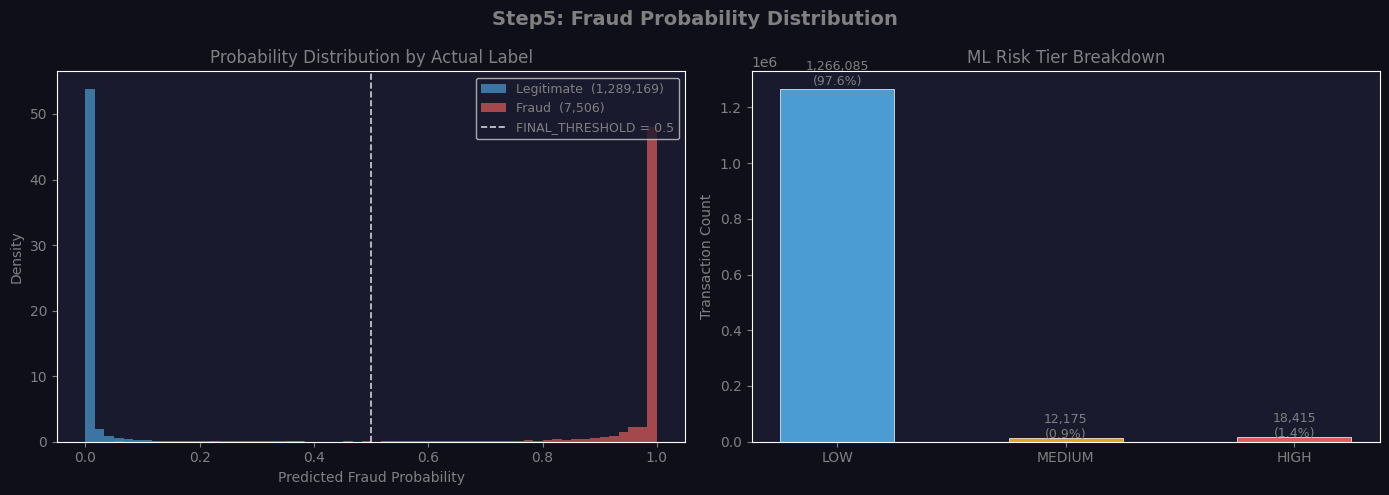

  Saved : step5_score_distribution.png


In [39]:
# ─────────────────────────────────────────────────────────────
# Fraud Probability Distribution
# ─────────────────────────────────────────────────────────────
# In this cell, I visualize the scoring results from the final model.
#
# After scoring all transactions, I want to understand how the model assigned fraud probabilities across the full dataset.
#
# I create two plots:
#
#   Left plot:
#     Shows the predicted fraud probability distribution for actual legitimate transactions and actual fraud transactions.
#
#   Right plot:
#     Shows how all transactions are distributed across the ML risk tiers:
#     LOW, MEDIUM, and HIGH.
#
# A strong model should usually place most legitimate transactions closer to 0 and most fraud transactions closer to 1, with as little overlap as possible.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')

fig.suptitle(
    'Step5: Fraud Probability Distribution',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Left Plot | Probability Distribution by Actual Label
# ─────────────────────────────────────────────────────────────
# This plot compares the fraud probability scores for:
#   - actual legitimate transactions
#   - actual fraud transactions
#
# This helps me check whether the model separates the two classes well.

ax = axes[0]
ax.set_facecolor('#1a1a2e')

# Split predicted probabilities by the actual label.
# These labels come from the original dataset.
legit_probs = full_probs[df['is_fraud'] == 0]
fraud_probs = full_probs[df['is_fraud'] == 1]

# Plot legitimate transaction probability distribution.
ax.hist(
    legit_probs,
    bins=60,
    alpha=0.7,
    color=PALETTE['legit'],
    label=f'Legitimate  ({len(legit_probs):,})',
    density=True
)

# Plot fraud transaction probability distribution.
ax.hist(
    fraud_probs,
    bins=60,
    alpha=0.7,
    color=PALETTE['fraud'],
    label=f'Fraud  ({len(fraud_probs):,})',
    density=True
)

# Mark the final deployment threshold.
# Transactions to the right of this line are flagged as fraud.
ax.axvline(
    x=FINAL_THRESHOLD,
    color='white',
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    label=f'FINAL_THRESHOLD = {FINAL_THRESHOLD}'
)

ax.set_title('Probability Distribution by Actual Label', color='gray')
ax.set_xlabel('Predicted Fraud Probability', color='gray')
ax.set_ylabel('Density', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray', fontsize=9)


# ─────────────────────────────────────────────────────────────
# Right Plot | ML Risk Tier Breakdown
# ─────────────────────────────────────────────────────────────
# This plot summarizes how many transactions fall into each ML risk tier.
#
# It gives a dashboard-friendly view of the model output:
#   LOW    : normal / low-priority transactions
#   MEDIUM : transactions worth monitoring
#   HIGH   : transactions that should be reviewed first

ax = axes[1]
ax.set_facecolor('#1a1a2e')

tier_order = ['LOW', 'MEDIUM', 'HIGH']
tier_colors = [PALETTE['legit'], '#E8A020', PALETTE['fraud']]
tier_vals = [tier_counts.get(t, 0) for t in tier_order]

bars = ax.bar(
    tier_order,
    tier_vals,
    color=tier_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.5
)

# Add count and percentage labels above each bar.
for bar, val in zip(bars, tier_vals):
    pct = val / len(df_predictions) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{val:,}\n({pct:.1f}%)',
        ha='center',
        color='gray',
        fontsize=9
    )

ax.set_title('ML Risk Tier Breakdown', color='gray')
ax.set_ylabel('Transaction Count', color='gray')
ax.tick_params(colors='gray')


# ─────────────────────────────────────────────────────────────
# Save and show
# ─────────────────────────────────────────────────────────────

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / 'step5_score_distribution.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

print('  Saved : step5_score_distribution.png')


The fraud probability distribution shows that the final XGBoost model separates legitimate and fraudulent transactions well.

Most legitimate transactions are concentrated near a fraud probability of 0, while most fraud transactions are concentrated near a fraud probability of 1. This means the model is confident for many transactions and provides a strong separation between the two classes.

The dashed vertical line represents the final deployment threshold of **0.50**. Transactions above this threshold are flagged as fraud. The chart supports the threshold decision because many true fraud transactions are clearly above the threshold.

The ML risk tier chart shows that most transactions are classified as `LOW` risk, while a smaller percentage are classified as `MEDIUM` or `HIGH` risk. This creates a practical review structure for Power BI, where analysts can focus first on high-risk transactions.



In [ ]:
# ─────────────────────────────────────────────────────────────
# SQL Server — Create MLPredictions Table and Load Data
# ─────────────────────────────────────────────────────────────
# In this cell, I load the ML prediction output into SQL Server.
#
# The table dbo.MLPredictions will store the scored model outputs:
#   - transaction number
#   - actual fraud label
#   - model fraud probability
#   - model fraud flag
#   - ML risk tier
#   - model version
#   - scoring timestamp
#
# I keep this table separate from FactTransaction so the original star schema stays clean.
# The table can be joined back to FactTransaction using trans_num.
#


from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import os

# Load .env from the etl folder because your project currently stores it there.
load_dotenv(ROOT / 'etl' / '.env')

SQL_ENABLED = True   # Set to False if you only want to preview the SQL logic


# ─────────────────────────────────────────────────────────────
# SQL DDL : Create dbo.MLPredictions if it does not exist
# ─────────────────────────────────────────────────────────────
# IF NOT EXISTS makes this safe to re-run.
#
# Important:
# This foreign key assumes dbo.FactTransaction has a trans_num column and that trans_num is unique or constrained as a key.

DDL = """
IF NOT EXISTS (
    SELECT 1
    FROM sys.tables
    WHERE name = 'MLPredictions'
      AND schema_id = SCHEMA_ID('dbo')
)
BEGIN
    CREATE TABLE dbo.MLPredictions (
        prediction_id   INT            IDENTITY(1,1) NOT NULL PRIMARY KEY,
        trans_num       VARCHAR(50)    NOT NULL,
        is_fraud        BIT            NOT NULL,
        ml_fraud_prob   DECIMAL(8,6)   NOT NULL,
        ml_fraud_flag   BIT            NOT NULL,
        ml_risk_tier    VARCHAR(10)    NOT NULL,
        model_version   VARCHAR(50)    NOT NULL,
        scored_at       DATETIME       NOT NULL DEFAULT GETDATE(),

        CONSTRAINT FK_ML_Trans FOREIGN KEY (trans_num)
            REFERENCES dbo.FactTransaction (trans_num)
    );

    PRINT 'dbo.MLPredictions created';
END
"""


if SQL_ENABLED:

    # ─────────────────────────────────────────────────────────
    # Read SQL Server settings from .env
    # ─────────────────────────────────────────────────────────
    server = os.getenv('SQL_SERVER')
    db = os.getenv('SQL_DATABASE')

    print('─── SQL Connection Settings ─────────────────')
    print(f'  SQL_SERVER   : {server}')
    print(f'  SQL_DATABASE : {db}')
    print()

    if not server or not db:
        raise ValueError(
            "SQL_SERVER or SQL_DATABASE is missing. "
            "Check your etl/.env file."
        )


    # ─────────────────────────────────────────────────────────
    # Build a safer pyodbc connection string
    # ─────────────────────────────────────────────────────────
    # URL.create with odbc_connect handles backslashes in SQLEXPRESS names .

    odbc_str = (
        "DRIVER={ODBC Driver 17 for SQL Server};"
        f"SERVER={server};"
        f"DATABASE={db};"
        "Trusted_Connection=yes;"
    )

    connection_url = URL.create(
        "mssql+pyodbc",
        query={"odbc_connect": odbc_str}
    )

    engine = create_engine(connection_url, fast_executemany=True)


    # ─────────────────────────────────────────────────────────
    # Test connection
    # ─────────────────────────────────────────────────────────
    # This confirms Python can reach SQL Server before creating/loading tables.

    with engine.connect() as conn:
        connected_db = conn.execute(text("SELECT DB_NAME()")).scalar()

    print(f'  Connected to database : {connected_db}')
    print()


    # ─────────────────────────────────────────────────────────
    # Create table if needed
    # ─────────────────────────────────────────────────────────

    with engine.connect() as conn:
        conn.execute(text(DDL))
        conn.commit()

    print('  dbo.MLPredictions table ready')


    # ─────────────────────────────────────────────────────────
    # Prevent duplicate loads for the same model version
    # ─────────────────────────────────────────────────────────
    # Since df_predictions uses model_version = xgboost_v1,
    # I delete old rows for this model version before inserting.
    #
    # This makes the cell safer to re-run.

    with engine.connect() as conn:
        conn.execute(text("""
            DELETE FROM dbo.MLPredictions
            WHERE model_version = 'xgboost_v1';
        """))
        conn.commit()

    print("  Old xgboost_v1 rows removed")


    # ─────────────────────────────────────────────────────────
    # Load predictions into SQL Server
    # ─────────────────────────────────────────────────────────
    # scored_at is not included in df_predictions.
    # SQL Server fills it automatically using DEFAULT GETDATE().

    df_predictions.to_sql(
        name='MLPredictions',
        con=engine,
        schema='dbo',
        if_exists='append',
        index=False,
        chunksize=1000,
        method='multi'
    )

    print(f'  {len(df_predictions):,} rows loaded → dbo.MLPredictions')


    # ─────────────────────────────────────────────────────────
    # Verify row count
    # ─────────────────────────────────────────────────────────

    with engine.connect() as conn:
        sql_count = conn.execute(text("""
            SELECT COUNT(*)
            FROM dbo.MLPredictions
            WHERE model_version = 'xgboost_v1';
        """)).scalar()

    print(f'  SQL row count verified : {sql_count:,}')


else:
    print('  SQL_ENABLED = False — skipping database load')
    print('  Set SQL_ENABLED = True and re-run when ready.')
    print()
    print(f'  Rows to load : {len(df_predictions):,}')
    print('  Join key     : trans_num → dbo.FactTransaction.trans_num')
    print()
    print('  DDL that will execute:')
    print(DDL)

─── SQL Connection Settings ─────────────────
  SQL_SERVER   : localhost\SQLEXPRESS
  SQL_DATABASE : FraudDB

  Connected to database : FraudDB

  dbo.MLPredictions table ready
  Old xgboost_v1 rows removed
  1,296,675 rows loaded → dbo.MLPredictions
  SQL row count verified : 1,296,675



The machine learning prediction output was successfully loaded into SQL Server.

The notebook connected to the `FraudDB` database, confirmed that `dbo.MLPredictions` was available, removed any previous `xgboost_v1` prediction rows, and loaded **1,296,675 scored transactions** into the table.

The SQL row count verification also returned **1,296,675 rows**, which matches the number of rows in the prediction DataFrame. This confirms that the full ML prediction output was loaded successfully.

The `dbo.MLPredictions` table can now be joined back to the transaction fact table using `trans_num`, allowing the final Power BI dashboard to include model probabilities, ML fraud flags, and ML risk tiers.

In [44]:

PBI_PATH = ROOT / 'data' / 'processed'

# ─────────────────────────────────────────────────────────────
# Save CSVs
# ─────────────────────────────────────────────────────────────
comparison.reset_index().to_csv(PBI_PATH / 'ml_model_comparison.csv', index=False)
print(f'  Saved : ml_model_comparison.csv')

threshold_df.to_csv(PBI_PATH / 'ml_threshold_curve.csv', index=False)
print(f'  Saved : ml_threshold_curve.csv')

print(f'  Already saved : ml_shap_importance.csv  (Step 4)')
print()


  Saved : ml_model_comparison.csv
  Saved : ml_threshold_curve.csv
  Already saved : ml_shap_importance.csv  (Step 4)

